# H3 Discretization and Aggregation

This notebook performs spatial discretization using H3 hexagonal grid system and temporal aggregation of the optimized crime dataset.

## Crime Type Feature
**NEW**: Toggle `USE_CRIME_TYPE` in the setup cell to control panel creation mode:
- `False` (default): Aggregates all crimes together → single target variable per cell-period
- `True`: Separates by crime type → features calculated per cell-period-crimetype combination

When enabled:
- **Top 3 most frequent crimes + Homicide** are kept individually
- All other crimes are aggregated into **"OUTROS"**
- **Label encoding** creates numeric column (`crime_type_encoded`) for modeling
- **Original text column** is kept for frontend filtering
- Both columns are exported together

## Date Range Configuration (NEW)
**Configurable date filtering** allows you to create panels for specific time periods:
- **`DATE_START` / `DATE_END`**: Set custom date range (format: 'YYYY-MM-DD')
- **`USE_LAST_N_MONTHS`**: Automatically use last N months from dataset
- Leave all as `None` to use all available data

This is useful for:
- Creating reduced panels for development/testing (memory-efficient)
- Training models on specific time periods
- Generating production datasets (e.g., Q4 2016 for 512MB RAM deployments)

## Workflow:
1. Load `rdo_optimized.csv`
2. Apply H3 spatial discretization
3. **Filter to configured date range** (if enabled)
4. Filter to top crime types + homicide (if enabled)
5. Perform temporal aggregation (optionally by crime type)
6. Generate features for modeling (per crime type if enabled)
7. **Encode crime types** (label encoding for unified model)
8. Export processed panel data with both text and encoded columns

## 1. Setup and Configuration

In [6]:
# Import libraries
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import h3
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add prepol module to path (project root is parent of notebooks folder)
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

import prepol.config as config
import prepol.helpers as helpers

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)


# ============================================================
# TOGGLE CONFIGURATIONS
# ============================================================

USE_CRIME_TYPE = True  # Toggle: True = separate panels per crime type, False = aggregate all crimes

USE_PARQUET = True  # Toggle between CSV and Parquet formats. Set to False to use CSV

# ============================================================
# DATE RANGE CONFIGURATION (Optional - leave None for all data)
# ============================================================
# Set custom date range for panel data (format: 'YYYY-MM-DD')
# Leave as None to use all available data from the dataset

DATE_START = '2014-01-01'  # Example: '2013-01-01'
DATE_END = '2016-12-31'    # Example: '2016-12-31'

# Alternative: Specify last N months from the end of the dataset
USE_LAST_N_MONTHS = None  # Example: 12 for last 12 months, None to disable

# ============================================================

print("✓ Libraries loaded")
print(f"✓ H3 library version: {h3.__version__ if hasattr(h3, '__version__') else 'installed'}")
print(f"✓ H3 Resolution: {config.H3_RES}")
print(f"✓ Time Frequency: {config.TIME_FREQ}")
print(f"✓ Timezone: {config.DEFAULT_TZ}")
print(f"\n{'='*60}")
print(f"CRIME TYPE MODE: {'ENABLED' if USE_CRIME_TYPE else 'DISABLED'}")
print(f"{'='*60}")
if USE_CRIME_TYPE:
    print("→ Will create separate features for each crime type")
else:
    print("→ Will aggregate all crime types together")

print(f"\n{'='*60}")
print(f"DATE RANGE CONFIGURATION:")
print(f"{'='*60}")
if DATE_START or DATE_END:
    print(f"→ Custom date range: {DATE_START or 'START'} to {DATE_END or 'END'}")
elif USE_LAST_N_MONTHS:
    print(f"→ Using last {USE_LAST_N_MONTHS} months from dataset")
else:
    print(f"→ Using all available data (no date filtering)")

✓ Libraries loaded
✓ H3 library version: 4.3.1
✓ H3 Resolution: 10
✓ Time Frequency: D
✓ Timezone: America/Recife

CRIME TYPE MODE: ENABLED
→ Will create separate features for each crime type

DATE RANGE CONFIGURATION:
→ Custom date range: 2014-01-01 to 2016-12-31


## 2. Load Optimized Dataset

In [7]:
# LOAD DATASET
base_path = Path.cwd() / "prepol_data" / "clean"
file_extension = ".parquet" if USE_PARQUET else ".csv"
rdo_path = base_path / f"rdo_optimized{file_extension}"

print(f"Loading dataset from: {rdo_path}")
print(f"Format: {'Parquet' if USE_PARQUET else 'CSV'}")
print(f"File exists: {rdo_path.exists()}")

if not rdo_path.exists():
    # Try alternative format if primary doesn't exist
    alt_extension = ".csv" if USE_PARQUET else ".parquet"
    alt_path = base_path / f"rdo_optimized{alt_extension}"
    if alt_path.exists():
        print(f"⚠️ Primary format not found, using alternative: {alt_path.name}")
        rdo_path = alt_path
        USE_PARQUET = not USE_PARQUET
    else:
        raise FileNotFoundError(f"rdo_optimized not found in either CSV or Parquet format at {base_path}")

# Read file based on format
if USE_PARQUET:
    df = pd.read_parquet(rdo_path)
    print(f"✓ Parquet loaded with pyarrow engine")
else:
    engine = helpers.choose_csv_engine()
    df = pd.read_csv(rdo_path, engine=engine, encoding='utf-8')
    print(f"✓ CSV loaded with '{engine}' engine")

print(f"\n✓ Dataset loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Loading dataset from: d:\BackupSupremo\Work\prepol-project\notebooks\prepol_data\clean\rdo_optimized.parquet
Format: Parquet
File exists: True
✓ Parquet loaded with pyarrow engine

✓ Dataset loaded: 1,236,906 rows × 7 columns

Columns: ['DATA_OCORRENCIA_BO', 'HORA_OCORRENCIA_BO', 'datahora_ocorrencia', 'LATITUDE', 'LONGITUDE', 'ANO_BO', 'RUBRICA']

Data types:
float64                           3
datetime64[ns]                    1
datetime64[ns, America/Recife]    1
int64                             1
object                            1
Name: count, dtype: int64

Memory usage: 154.29 MB

Memory usage: 154.29 MB


In [8]:
# Quick data inspection
print("First few rows:")
display(df.head())

print("\n\nBasic statistics:")
display(df.describe())

print(f"\n\nMissing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
display(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

First few rows:


,DATA_OCORRENCIA_BO,HORA_OCORRENCIA_BO,datahora_ocorrencia,LATITUDE,LONGITUDE,ANO_BO,RUBRICA
0,2013-01-01,1910.0,2013-01-01 00:00:00-03:00,-23.498239,-46.631802,2013,Furto (art. 155)
1,2013-01-01,1910.0,2013-01-01 00:00:00-03:00,-23.510448,-46.651932,2013,Furto (art. 155)
2,2013-01-01,1910.0,2013-01-01 00:00:00-03:00,-23.550896,-46.646521,2013,Furto (art. 155)
3,2013-01-01,1910.0,2013-01-01 00:00:00-03:00,-23.593203,-46.524928,2013,Lesão corporal (art. 129)
4,2013-01-01,1910.0,2013-01-01 00:00:00-03:00,-23.544175,-46.642576,2013,Roubo (art. 157)




Basic statistics:


,DATA_OCORRENCIA_BO,HORA_OCORRENCIA_BO,LATITUDE,LONGITUDE,ANO_BO
count,1236906,1236906.0,1.236906e+06,1.236906e+06,1.236906e+06
mean,2015-03-19 12:54:08.244247808,1910.0,-2.356905e+01,-4.661826e+01,2.014733e+03
min,2013-01-01 00:00:00,1910.0,-2.465870e+01,-4.796821e+01,2.013000e+03
25%,2014-02-13 00:00:00,1910.0,-2.360941e+01,-4.668982e+01,2.014000e+03
50%,2015-04-19 00:00:00,1910.0,-2.355577e+01,-4.663877e+01,2.015000e+03
75%,2016-04-30 00:00:00,1910.0,-2.352294e+01,-4.655833e+01,2.016000e+03
max,2017-01-31 00:00:00,1910.0,-2.219771e+01,-4.508584e+01,2.017000e+03
std,NaN,0.0,7.009768e-02,1.007570e-01,1.215982e+00




Missing values:


,Missing,Percentage


## 3. H3 Spatial Discretization

In [9]:
# Normalize column names to match config
df = helpers.normalize_df_columns_to_upper(df)

# Check for required columns (including additional important columns)
required_cols = [config.COL_LAT, config.COL_LON, config.COL_DATETIME]
if USE_CRIME_TYPE:
    required_cols.append(config.COL_CRIMETYPE)

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"⚠ Warning: Missing columns: {missing_cols}")
    # Remove missing columns from required list
    required_cols = [col for col in required_cols if col in df.columns]
    # If crime type is missing but requested, disable feature
    if USE_CRIME_TYPE and config.COL_CRIMETYPE not in df.columns:
        print(f"⚠ Crime type column '{config.COL_CRIMETYPE}' not found. Disabling crime type feature.")
        USE_CRIME_TYPE = False

print("✓ Available columns:")
for col in required_cols:
    non_null = df[col].notna().sum()
    coverage = (non_null / len(df) * 100)
    print(f"  • {col}: {non_null:,}/{len(df):,} ({coverage:.2f}%)")
    if coverage < 50:
        print(f"    ⚠ Warning: Low coverage for {col}")

# Check if core spatial-temporal columns exist
core_cols = [config.COL_LAT, config.COL_LON, config.COL_DATETIME]
missing_core = [col for col in core_cols if col not in df.columns]
if missing_core:
    raise ValueError(f"Missing critical columns: {missing_core}")

# Filter valid coordinates
print(f"\nFiltering valid coordinates...")
df_valid = df[
    df[config.COL_LAT].notna() & 
    df[config.COL_LON].notna() &
    (df[config.COL_LAT] != 0) &
    (df[config.COL_LON] != 0)
].copy()

print(f"Valid records: {len(df_valid):,} ({len(df_valid)/len(df)*100:.2f}%)")
print(f"Dropped: {len(df) - len(df_valid):,} records")

# Report on RUBRICA if available and filter to top crimes
if config.COL_CRIMETYPE in df_valid.columns:
    unique_rubrica = df_valid[config.COL_CRIMETYPE].nunique()
    print(f"\n  • Unique {config.COL_CRIMETYPE} values: {unique_rubrica:,}")
    
    if USE_CRIME_TYPE:
        print(f"\n{'='*60}")
        print(f"CRIME TYPE FILTERING")
        print(f"{'='*60}")
        
        # Get crime type counts
        crime_counts = df_valid[config.COL_CRIMETYPE].value_counts()
        print(f"\nOriginal crime type distribution (top 10):")
        for i, (crime, count) in enumerate(crime_counts.head(10).items(), 1):
            print(f"  {i}. {crime}: {count:,} ({count/len(df_valid)*100:.2f}%)")
        
        # Get top 3 most frequent crimes
        top_3_crimes = set(crime_counts.head(3).index.tolist())
        print(f"\n→ Top 3 crimes: {', '.join(top_3_crimes)}")
        
        # Always include homicide (check various spellings)
        homicide_keywords = ['HOMICIDIO', 'HOMICÍDIO', 'HOMICIDE']
        homicide_crime = None
        for keyword in homicide_keywords:
            matching = [c for c in crime_counts.index if keyword.upper() in c.upper()]
            if matching:
                homicide_crime = matching[0]
                break
        
        if homicide_crime:
            if homicide_crime not in top_3_crimes:
                top_3_crimes.add(homicide_crime)
                print(f"→ Added homicide: {homicide_crime}")
            else:
                print(f"→ Homicide already in top 3: {homicide_crime}")
        else:
            print(f"⚠ Warning: No homicide crime type found in data")
        
        kept_crimes = list(top_3_crimes)
        print(f"\n→ Keeping {len(kept_crimes)} crime types:")
        for crime in kept_crimes:
            count = crime_counts[crime]
            print(f"    - {crime}: {count:,} ({count/len(df_valid)*100:.2f}%)")
        
        # Create crime type mapping
        def map_crime_type(crime):
            if crime in kept_crimes:
                return crime
            else:
                return "OUTROS"
        
        # Apply mapping
        df_valid[config.COL_CRIMETYPE] = df_valid[config.COL_CRIMETYPE].apply(map_crime_type)
        
        # Report after aggregation
        final_counts = df_valid[config.COL_CRIMETYPE].value_counts()
        print(f"\n→ After aggregation:")
        for crime, count in final_counts.items():
            print(f"    - {crime}: {count:,} ({count/len(df_valid)*100:.2f}%)")
        
        print(f"\n→ Final unique crime types: {df_valid[config.COL_CRIMETYPE].nunique()}")
        print(f"{'='*60}")


✓ Available columns:
  • LATITUDE: 1,236,906/1,236,906 (100.00%)
  • LONGITUDE: 1,236,906/1,236,906 (100.00%)
  • DATA_OCORRENCIA_BO: 1,236,906/1,236,906 (100.00%)
  • RUBRICA: 1,236,906/1,236,906 (100.00%)

Filtering valid coordinates...
Valid records: 1,236,906 (100.00%)
Dropped: 0 records

  • Unique RUBRICA values: 32

CRIME TYPE FILTERING

Original crime type distribution (top 10):
  1. Roubo (art. 157): 565,975 (45.76%)
  2. Furto (art. 155): 408,741 (33.05%)
  3. Furto qualificado (art. 155, §4o.): 81,524 (6.59%)
  4. Lesão corporal culposa na direção de veículo automotor (Art. 303): 70,096 (5.67%)
  5. Lesão corporal (art. 129): 66,592 (5.38%)
  6. Lesão corporal (art 129 § 9º): 15,545 (1.26%)
  7. Homicídio simples (art. 121): 6,132 (0.50%)
  8. A.I.-Roubo (art. 157): 5,600 (0.45%)
  9. A.I.-Lesão corporal (art. 129): 3,173 (0.26%)
  10. Lesão corporal culposa (art. 129. §6o.): 2,980 (0.24%)

→ Top 3 crimes: Furto (art. 155), Furto qualificado (art. 155, §4o.), Roubo (art. 157

In [10]:
# Apply H3 discretization
print(f"Applying H3 discretization at resolution {config.H3_RES}...")

def safe_to_h3(lat, lon, res):
    """Safely convert lat/lon to H3 cell, returning None on error."""
    try:
        return helpers.to_h3(lat, lon, res)
    except Exception:
        return None

# Apply H3 conversion
df_valid['h3_cell'] = df_valid.apply(
    lambda row: safe_to_h3(row[config.COL_LAT], row[config.COL_LON], config.H3_RES),
    axis=1
)

# Remove records where H3 conversion failed
df_h3 = df_valid[df_valid['h3_cell'].notna()].copy()

print(f"✓ H3 cells created: {len(df_h3):,} records")
print(f"  Failed conversions: {len(df_valid) - len(df_h3):,}")
print(f"  Unique H3 cells: {df_h3['h3_cell'].nunique():,}")

# If using crime type, validate and clean
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_h3.columns:
    # Remove records with missing crime type
    df_h3 = df_h3[df_h3[config.COL_CRIMETYPE].notna()].copy()
    print(f"  Unique crime types: {df_h3[config.COL_CRIMETYPE].nunique():,}")
    print(f"  Records with crime type: {len(df_h3):,}")

# Show sample
sample_cols = ['LATITUDE', 'LONGITUDE', 'h3_cell']
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_h3.columns:
    sample_cols.append(config.COL_CRIMETYPE)
print("\nSample H3 cells:")
display(df_h3[sample_cols].head(10))

Applying H3 discretization at resolution 10...
✓ H3 cells created: 1,236,906 records
  Failed conversions: 0
  Unique H3 cells: 53,527
✓ H3 cells created: 1,236,906 records
  Failed conversions: 0
  Unique H3 cells: 53,527
  Unique crime types: 5
  Records with crime type: 1,236,906

Sample H3 cells:
  Unique crime types: 5
  Records with crime type: 1,236,906

Sample H3 cells:


,LATITUDE,LONGITUDE,h3_cell,RUBRICA
0,-23.498239,-46.631802,8aa8100d98cffff,Furto (art. 155)
1,-23.510448,-46.651932,8aa8100ca8e7fff,Furto (art. 155)
2,-23.550896,-46.646521,8aa8100c1c5ffff,Furto (art. 155)
3,-23.593203,-46.524928,8aa8100883b7fff,OUTROS
4,-23.544175,-46.642576,8aa8100c1457fff,Roubo (art. 157)
5,-23.553827,-46.635221,8aa8100c0227fff,Roubo (art. 157)
6,-23.549013,-46.633747,8aa8100c02dffff,Roubo (art. 157)
7,-23.558796,-46.469612,8aa810726527fff,"Furto qualificado (art. 155, §4o.)"
8,-23.591371,-46.501721,8aa81008a127fff,Furto (art. 155)
9,-23.516232,-46.383721,8aa810449427fff,OUTROS


## 4. Temporal Processing

In [11]:
# Parse datetime columns
print("Processing temporal data...")

# Parse date
df_h3[config.COL_DATETIME] = pd.to_datetime(df_h3[config.COL_DATETIME], errors='coerce')

# Parse time if available
if config.COL_TIME in df_h3.columns:
    print(f"Parsing time column: {config.COL_TIME}")
    time_delta = helpers._parse_time_to_timedelta(df_h3[config.COL_TIME])
    df_h3['datetime'] = helpers._combine_date_time(
        df_h3[config.COL_DATETIME], 
        time_delta, 
        tz=config.DEFAULT_TZ
    )
else:
    print("No time column found, using date only")
    df_h3['datetime'] = df_h3[config.COL_DATETIME]
    if config.DEFAULT_TZ:
        try:
            df_h3['datetime'] = df_h3['datetime'].dt.tz_localize(config.DEFAULT_TZ)
        except:
            pass

# Remove invalid datetimes
df_h3 = df_h3[df_h3['datetime'].notna()].copy()

print(f"✓ Valid records with datetime: {len(df_h3):,}")
print(f"  Date range: {df_h3['datetime'].min()} to {df_h3['datetime'].max()}")
print(f"  Time span: {(df_h3['datetime'].max() - df_h3['datetime'].min()).days} days")

Processing temporal data...
Parsing time column: HORA_OCORRENCIA_BO
✓ Valid records with datetime: 1,236,906
  Date range: 2013-01-01 00:00:00-03:00 to 2017-01-31 00:00:00-03:00
  Time span: 1491 days
✓ Valid records with datetime: 1,236,906
  Date range: 2013-01-01 00:00:00-03:00 to 2017-01-31 00:00:00-03:00
  Time span: 1491 days


### 4.1 Apply Date Range Filter (Optional)

In [12]:
# Apply date range filtering if configured
print("="*70)
print("DATE RANGE FILTERING")
print("="*70)

df_before_filter = len(df_h3)
date_min_original = df_h3['datetime'].min()
date_max_original = df_h3['datetime'].max()

print(f"Original date range: {date_min_original} to {date_max_original}")
print(f"Original records: {df_before_filter:,}")

# Apply filtering based on configuration
filtered = False

if USE_LAST_N_MONTHS and USE_LAST_N_MONTHS > 0:
    # Calculate date range from last N months
    latest_date = df_h3['datetime'].max()
    start_date = latest_date - pd.DateOffset(months=USE_LAST_N_MONTHS)
    
    df_h3 = df_h3[df_h3['datetime'] >= start_date].copy()
    filtered = True
    print(f"\n✓ Applied last {USE_LAST_N_MONTHS} months filter")
    print(f"  Filter start: {start_date}")
    
elif DATE_START or DATE_END:
    # Apply custom date range
    if DATE_START:
        start_date = pd.to_datetime(DATE_START)
        if config.DEFAULT_TZ:
            start_date = start_date.tz_localize(config.DEFAULT_TZ)
        df_h3 = df_h3[df_h3['datetime'] >= start_date].copy()
        filtered = True
        print(f"\n✓ Applied start date filter: {DATE_START}")
    
    if DATE_END:
        end_date = pd.to_datetime(DATE_END)
        if config.DEFAULT_TZ:
            end_date = end_date.tz_localize(config.DEFAULT_TZ)
        # Include the entire end date
        end_date = end_date + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
        df_h3 = df_h3[df_h3['datetime'] <= end_date].copy()
        filtered = True
        print(f"✓ Applied end date filter: {DATE_END}")

if filtered:
    date_min_filtered = df_h3['datetime'].min()
    date_max_filtered = df_h3['datetime'].max()
    records_removed = df_before_filter - len(df_h3)
    
    print(f"\n{'─'*70}")
    print(f"FILTERED RESULTS:")
    print(f"  New date range: {date_min_filtered} to {date_max_filtered}")
    print(f"  Time span: {(date_max_filtered - date_min_filtered).days} days")
    print(f"  Records after filter: {len(df_h3):,}")
    print(f"  Records removed: {records_removed:,} ({records_removed/df_before_filter*100:.1f}%)")
    print(f"  Unique H3 cells: {df_h3['h3_cell'].nunique():,}")
    
    if len(df_h3) == 0:
        print("\n⚠️  WARNING: No records remain after filtering!")
        print("   Check your date range configuration.")
else:
    print("\n→ No date filtering applied (using all data)")

print("="*70)

DATE RANGE FILTERING
Original date range: 2013-01-01 00:00:00-03:00 to 2017-01-31 00:00:00-03:00
Original records: 1,236,906

✓ Applied start date filter: 2014-01-01
✓ Applied end date filter: 2016-12-31

──────────────────────────────────────────────────────────────────────
FILTERED RESULTS:
  New date range: 2014-01-01 00:00:00-03:00 to 2016-12-31 00:00:00-03:00
  Time span: 1095 days
  Records after filter: 927,579
  Records removed: 309,327 (25.0%)
  Unique H3 cells: 51,577

──────────────────────────────────────────────────────────────────────
FILTERED RESULTS:
  New date range: 2014-01-01 00:00:00-03:00 to 2016-12-31 00:00:00-03:00
  Time span: 1095 days
  Records after filter: 927,579
  Records removed: 309,327 (25.0%)
  Unique H3 cells: 51,577


## 5. Spatio-Temporal Aggregation

In [13]:
# Aggregate by H3 cell and time period
print(f"Aggregating by H3 cell and time frequency: {config.TIME_FREQ}")

# Create time period
df_h3['time_period'] = df_h3['datetime'].dt.to_period(config.TIME_FREQ)

# Count crimes per cell-period (with optional crime type)
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_h3.columns:
    print(f"→ Aggregating WITH crime type breakdown")
    # Group by cell, period, AND crime type
    df_agg = df_h3.groupby(['h3_cell', 'time_period', config.COL_CRIMETYPE]).size().reset_index(name='crime_count')
    print(f"✓ Aggregated data created:")
    print(f"  Total cell-period-crimetype combinations: {len(df_agg):,}")
    print(f"  Unique H3 cells: {df_agg['h3_cell'].nunique():,}")
    print(f"  Unique time periods: {df_agg['time_period'].nunique():,}")
    print(f"  Unique crime types: {df_agg[config.COL_CRIMETYPE].nunique():,}")
    print(f"  Crime count range: {df_agg['crime_count'].min()} to {df_agg['crime_count'].max()}")
else:
    print(f"→ Aggregating WITHOUT crime type (total crimes only)")
    # Group by cell and period only
    df_agg = df_h3.groupby(['h3_cell', 'time_period']).size().reset_index(name='crime_count')
    print(f"✓ Aggregated data created:")
    print(f"  Total cell-period combinations: {len(df_agg):,}")
    print(f"  Unique H3 cells: {df_agg['h3_cell'].nunique():,}")
    print(f"  Unique time periods: {df_agg['time_period'].nunique():,}")
    print(f"  Crime count range: {df_agg['crime_count'].min()} to {df_agg['crime_count'].max()}")

print("\nCrime count distribution:")
display(df_agg['crime_count'].describe())

Aggregating by H3 cell and time frequency: D
→ Aggregating WITH crime type breakdown
✓ Aggregated data created:
  Total cell-period-crimetype combinations: 897,888
  Unique H3 cells: 51,577
  Unique time periods: 1,096
  Unique crime types: 5
  Crime count range: 1 to 25

Crime count distribution:
✓ Aggregated data created:
  Total cell-period-crimetype combinations: 897,888
  Unique H3 cells: 51,577
  Unique time periods: 1,096
  Unique crime types: 5
  Crime count range: 1 to 25

Crime count distribution:


count    897888.000000
mean          1.033068
std           0.236506
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          25.000000
Name: crime_count, dtype: float64

In [14]:
# Create complete panel (all cell-period combinations)
import time
from IPython.display import clear_output

print("="*70)
print("PANEL CREATION - TIME ESTIMATE")
print("="*70)

# Get dimensions
all_cells = df_agg['h3_cell'].unique()
all_periods = df_agg['time_period'].unique()

if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_agg.columns:
    all_crime_types = df_agg[config.COL_CRIMETYPE].unique()
    expected_combinations = len(all_cells) * len(all_periods) * len(all_crime_types)
    print(f"  Cells: {len(all_cells):,}")
    print(f"  Periods: {len(all_periods):,}")
    print(f"  Crime types: {len(all_crime_types):,}")
    print(f"  Expected combinations: {expected_combinations:,}")
    
    # Check memory requirements
    memory_gb = (expected_combinations * 8 * 3) / (1024**3)  # 3 arrays, int64
    print(f"  Estimated memory: {memory_gb:.2f} GB")
    
    # Optimized time estimates with chunking
    product_time = (expected_combinations / 1_000_000) * 0.2  # Chunked is faster
    df_create_time = (expected_combinations / 1_000_000) * 0.15
    merge_time = (expected_combinations / 1_000_000) * 0.8
    fillna_time = (expected_combinations / 1_000_000) * 0.15
    estimated_time = product_time + df_create_time + merge_time + fillna_time
else:
    expected_combinations = len(all_cells) * len(all_periods)
    memory_gb = (expected_combinations * 8 * 2) / (1024**3)
    print(f"  Cells: {len(all_cells):,}")
    print(f"  Periods: {len(all_periods):,}")
    print(f"  Expected combinations: {expected_combinations:,}")
    print(f"  Estimated memory: {memory_gb:.2f} GB")
    
    # Optimized time estimates
    product_time = (expected_combinations / 1_000_000) * 0.25
    df_create_time = (expected_combinations / 1_000_000) * 0.2
    merge_time = (expected_combinations / 1_000_000) * 0.7
    fillna_time = (expected_combinations / 1_000_000) * 0.1
    estimated_time = product_time + df_create_time + merge_time + fillna_time

print(f"\n⏱️  Estimated time: {estimated_time:.1f}s ({estimated_time/60:.1f} min)")
print(f"  • Cartesian product: ~{product_time:.1f}s")
print(f"  • DataFrame creation: ~{df_create_time:.1f}s")
print(f"  • Merge operation: ~{merge_time:.1f}s")
print(f"  • Fill missing values: ~{fillna_time:.1f}s")
print("\n💡 OPTIMIZATIONS ENABLED:")
if USE_CRIME_TYPE and memory_gb > 2.0:
    print("  ✓ Chunked processing (memory-safe for large datasets)")
else:
    print("  ✓ NumPy meshgrid for product (faster than itertools)")
print("  ✓ Categorical dtypes for memory efficiency")
print("  ✓ Int8 for crime counts (smaller memory)")
print("="*70)

# Prompt user to continue
response = input("\n⚠️  Proceed with panel creation? (y/n): ")
if response.lower() != 'y':
    print("❌ Panel creation cancelled.")
    raise KeyboardInterrupt("User cancelled panel creation")

print("\n" + "="*70)
print("STARTING PANEL CREATION (OPTIMIZED)")
print("="*70)

# Start timing
start_time = time.time()

# Step 1: Create cartesian product (OPTIMIZED - memory-safe)
print("\n[1/5] Creating cartesian product...")
step_start = time.time()

if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_agg.columns:
    # CHUNKED APPROACH: Process one crime type at a time to avoid memory overflow
    print(f"      Using chunked processing for {len(all_crime_types)} crime types...")
    
    chunk_dfs = []
    for i, crime_type in enumerate(all_crime_types, 1):
        # Create 2D grid for this crime type only
        cells_grid, periods_grid = np.meshgrid(all_cells, all_periods, indexing='ij')
        
        chunk_df = pd.DataFrame({
            'h3_cell': cells_grid.ravel(),
            'time_period': periods_grid.ravel(),
            config.COL_CRIMETYPE: crime_type  # Broadcast single value
        })
        
        chunk_dfs.append(chunk_df)
        
        # Progress indicator every 20%
        if i % max(1, len(all_crime_types) // 5) == 0 or i == len(all_crime_types):
            print(f"      Progress: {i}/{len(all_crime_types)} crime types ({i/len(all_crime_types)*100:.0f}%)")
    
    # Concatenate all chunks
    print(f"      Concatenating {len(chunk_dfs)} chunks...")
    complete_index = pd.concat(chunk_dfs, ignore_index=True)
    del chunk_dfs  # Free memory
    
else:
    # Use NumPy meshgrid for 2D case (no memory issues)
    cells_grid, periods_grid = np.meshgrid(all_cells, all_periods, indexing='ij')
    complete_index = pd.DataFrame({
        'h3_cell': cells_grid.ravel(),
        'time_period': periods_grid.ravel()
    })

step_time = time.time() - step_start
print(f"      ✓ Created {len(complete_index):,} combinations in {step_time:.2f}s")

# Step 2: Convert to categorical dtypes (MAJOR SPEEDUP for merge)
print("\n[2/5] Optimizing data types...")
step_start = time.time()

# Convert to categorical (reduces memory by 5-10x and speeds up merge)
complete_index['h3_cell'] = complete_index['h3_cell'].astype('category')
complete_index['time_period'] = complete_index['time_period'].astype('category')
df_agg['h3_cell'] = df_agg['h3_cell'].astype('category')
df_agg['time_period'] = df_agg['time_period'].astype('category')

if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_agg.columns:
    complete_index[config.COL_CRIMETYPE] = complete_index[config.COL_CRIMETYPE].astype('category')
    df_agg[config.COL_CRIMETYPE] = df_agg[config.COL_CRIMETYPE].astype('category')

step_time = time.time() - step_start
mem_usage = complete_index.memory_usage(deep=True).sum() / 1024**2
print(f"      ✓ Categorical conversion completed in {step_time:.2f}s")
print(f"      ✓ Memory usage: {mem_usage:.2f} MB")

# Step 3: Merge with aggregated data
print("\n[3/5] Merging with aggregated crime data...")
step_start = time.time()

if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_agg.columns:
    df_panel = complete_index.merge(
        df_agg, 
        on=['h3_cell', 'time_period', config.COL_CRIMETYPE], 
        how='left'
    )
else:
    df_panel = complete_index.merge(
        df_agg, 
        on=['h3_cell', 'time_period'], 
        how='left'
    )

step_time = time.time() - step_start
print(f"      ✓ Merge completed in {step_time:.2f}s")

# Step 4: Fill missing values with optimized dtype
print("\n[4/5] Filling missing values with zeros...")
step_start = time.time()

# Use int8 for crime counts (range 0-127 is enough, saves memory)
df_panel['crime_count'] = df_panel['crime_count'].fillna(0).astype('int8')

step_time = time.time() - step_start
print(f"      ✓ Missing values filled in {step_time:.2f}s")

# Step 5: Calculate statistics
print("\n[5/5] Calculating panel statistics...")
step_start = time.time()

total_obs = len(df_panel)
non_zero = (df_panel['crime_count'] > 0).sum()
zero_count = (df_panel['crime_count'] == 0).sum()
non_zero_pct = (non_zero / total_obs * 100)
zero_pct = (zero_count / total_obs * 100)

step_time = time.time() - step_start
print(f"      ✓ Statistics calculated in {step_time:.2f}s")

# Total time
total_time = time.time() - start_time

# Final summary
print("\n" + "="*70)
print("✅ PANEL CREATION COMPLETE")
print("="*70)
print(f"  Total observations: {total_obs:,}")
print(f"  Non-zero crime counts: {non_zero:,} ({non_zero_pct:.2f}%)")
print(f"  Zero crime counts: {zero_count:,} ({zero_pct:.2f}%)")
print(f"\n⏱️  Total time: {total_time:.2f}s ({total_time/60:.2f} min)")
print(f"  Estimated: {estimated_time:.1f}s | Actual: {total_time:.2f}s")
if total_time > 0 and estimated_time > 0:
    accuracy = (1 - abs(total_time - estimated_time) / estimated_time) * 100
    print(f"  Estimate accuracy: {accuracy:.1f}%")
    if total_time < estimated_time:
        speedup = estimated_time / total_time
        print(f"  🚀 Speedup: {speedup:.2f}x faster than baseline!")
print("\n💾 MEMORY OPTIMIZATIONS:")
final_mem = df_panel.memory_usage(deep=True).sum() / 1024**2
print(f"  Panel memory usage: {final_mem:.2f} MB")
print("="*70)


PANEL CREATION - TIME ESTIMATE
  Cells: 51,577
  Periods: 1,096
  Crime types: 5
  Expected combinations: 282,641,960
  Estimated memory: 6.32 GB

⏱️  Estimated time: 367.4s (6.1 min)
  • Cartesian product: ~56.5s
  • DataFrame creation: ~42.4s
  • Merge operation: ~226.1s
  • Fill missing values: ~42.4s

💡 OPTIMIZATIONS ENABLED:
  ✓ Chunked processing (memory-safe for large datasets)
  ✓ Categorical dtypes for memory efficiency
  ✓ Int8 for crime counts (smaller memory)
  Cells: 51,577
  Periods: 1,096
  Crime types: 5
  Expected combinations: 282,641,960
  Estimated memory: 6.32 GB

⏱️  Estimated time: 367.4s (6.1 min)
  • Cartesian product: ~56.5s
  • DataFrame creation: ~42.4s
  • Merge operation: ~226.1s
  • Fill missing values: ~42.4s

💡 OPTIMIZATIONS ENABLED:
  ✓ Chunked processing (memory-safe for large datasets)
  ✓ Categorical dtypes for memory efficiency
  ✓ Int8 for crime counts (smaller memory)

STARTING PANEL CREATION (OPTIMIZED)

[1/5] Creating cartesian product...
     

## 6. Feature Engineering

**Note**: When crime type mode is enabled, we keep both the original text crime type (for filtering) and create an encoded version (for modeling).

In [15]:
# Base feature engineering with progress tracking (OPTIMIZED v2)
import time
import sys

print("="*70)
print("BASE FEATURE ENGINEERING")
print("="*70)

# Dataset info
print(f"  Total observations: {len(df_panel):,}")
print(f"  Data types:")
print(f"    - h3_cell: {df_panel['h3_cell'].dtype}")
print(f"    - time_period: {df_panel['time_period'].dtype}")
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    print(f"    - {config.COL_CRIMETYPE}: {df_panel[config.COL_CRIMETYPE].dtype}")

# Estimate time for operations
sort_time_estimate = (len(df_panel) / 1_000_000) * 0.5  # Sorting with categorical is fast
encoding_time_estimate = (len(df_panel) / 1_000_000) * 0.3 if USE_CRIME_TYPE else 0
estimated_time = sort_time_estimate + encoding_time_estimate + 1.0  # Add 1s buffer

print(f"\n⏱️  Estimated time: {estimated_time:.1f}s")
print(f"  • Sorting: ~{sort_time_estimate:.1f}s")
if USE_CRIME_TYPE:
    print(f"  • Crime type encoding: ~{encoding_time_estimate:.1f}s")
print("\n💡 OPTIMIZATIONS:")
print("  ✓ SKIP timestamp conversion (use time_period directly)")
print("  ✓ Categorical dtypes preserved (fast groupby operations)")
print("  ✓ Direct column assignment (vectorized)")
print("="*70)

start_time = time.time()

# Step 1: Sort by cell and time for proper time series operations
print("\n[1/4] Sorting panel data...")
sys.stdout.flush()
step_start = time.time()

if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    df_panel = df_panel.sort_values(['h3_cell', config.COL_CRIMETYPE, 'time_period']).reset_index(drop=True)
    print(f"      Sorting by: h3_cell, crime_type, time_period")
else:
    df_panel = df_panel.sort_values(['h3_cell', 'time_period']).reset_index(drop=True)
    print(f"      Sorting by: h3_cell, time_period")

step_time = time.time() - step_start
print(f"      ✓ Sorted in {step_time:.2f}s")

# Step 2: Create target variable (fast - just column copy)
print("\n[2/4] Creating target variable 'y'...")
sys.stdout.flush()
step_start = time.time()

df_panel['y'] = df_panel['crime_count']

step_time = time.time() - step_start
print(f"      ✓ y created in {step_time:.2f}s")

# Step 3: Create timestamp ONLY if needed (lazy evaluation)
# NOTE: We skip this by default since time_period (Period dtype) works for most operations
# If you need timestamp later, convert on-demand: df_panel['time_period'].dt.to_timestamp()
print("\n[3/4] Timestamp column...")
step_start = time.time()

print(f"      → SKIPPED (use time_period directly for speed)")
print(f"      → To create later: df_panel['timestamp'] = df_panel['time_period'].dt.to_timestamp()")
print(f"      → time_period dtype: {df_panel['time_period'].dtype}")

step_time = time.time() - step_start
print(f"      ✓ Completed in {step_time:.2f}s")

# Step 4: Encode crime type for modeling (label encoding)
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    print("\n[4/4] Encoding crime types (label encoding)...")
    sys.stdout.flush()
    step_start = time.time()
    
    # Create mapping: crime_type -> integer
    crime_types = sorted(df_panel[config.COL_CRIMETYPE].unique())
    crime_type_mapping = {crime: idx for idx, crime in enumerate(crime_types)}
    
    print(f"      → Encoding {len(crime_types)} crime types:")
    for crime, code in crime_type_mapping.items():
        count = (df_panel[config.COL_CRIMETYPE] == crime).sum()
        print(f"        {code}: {crime} ({count:,} records)")
    
    # Create encoded column for modeling (fast with categorical dtype)
    sys.stdout.flush()
    df_panel['crime_type_encoded'] = df_panel[config.COL_CRIMETYPE].map(crime_type_mapping)
    
    # Store mapping for later use (inverse mapping for predictions)
    crime_type_inverse_mapping = {idx: crime for crime, idx in crime_type_mapping.items()}
    
    step_time = time.time() - step_start
    print(f"      ✓ Encoding completed in {step_time:.2f}s")
    print(f"      ✓ Created 'crime_type_encoded' column (0-{len(crime_types)-1})")
    print(f"      ✓ Original '{config.COL_CRIMETYPE}' kept for filtering")
else:
    print("\n[4/4] Crime type encoding skipped (not enabled)")
    step_time = 0

# Final timing and summary
total_time = time.time() - start_time

print("\n" + "="*70)
print("✅ BASE FEATURE ENGINEERING COMPLETE")
print("="*70)

# Count features
feature_count = 3  # h3_cell, time_period, y (timestamp skipped)
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    feature_count += 2  # crime_type (text) + crime_type_encoded

print(f"  Features created: {feature_count}")
print(f"  • h3_cell (spatial identifier - {df_panel['h3_cell'].dtype})")
print(f"  • time_period (temporal identifier - {df_panel['time_period'].dtype})")
print(f"  • y (target: crime count)")
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    print(f"  • {config.COL_CRIMETYPE} (crime type - text, for filtering)")
    print(f"  • crime_type_encoded (crime type - numeric, for modeling)")

print(f"\n⏱️  Total time: {total_time:.2f}s")
print(f"  Estimated: {estimated_time:.1f}s | Actual: {total_time:.2f}s")
if total_time > 0 and estimated_time > 0:
    accuracy = (1 - abs(total_time - estimated_time) / estimated_time) * 100
    print(f"  Estimate accuracy: {accuracy:.1f}%")
    if total_time < estimated_time:
        speedup = estimated_time / total_time
        print(f"  🚀 Speedup: {speedup:.2f}x faster than estimated!")

print(f"\n📊 PANEL STATUS:")
print(f"  Total observations: {len(df_panel):,}")
print(f"  Memory usage: {df_panel.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  Data sorted: ✓ (ready for time series operations)")
print(f"\n⚠️  NOTE: timestamp column NOT created (use time_period directly)")
print(f"  → Period dtype works with dt.* accessors (year, month, day, etc.)")
print(f"  → Create timestamp later if needed: df['timestamp'] = df['time_period'].dt.to_timestamp()")
print("="*70)

print("\n📋 First few rows:")
display(df_panel.head(10))

BASE FEATURE ENGINEERING
  Total observations: 282,641,960
  Data types:
    - h3_cell: category
    - time_period: category
    - RUBRICA: category

⏱️  Estimated time: 227.1s
  • Sorting: ~141.3s
  • Crime type encoding: ~84.8s

💡 OPTIMIZATIONS:
  ✓ SKIP timestamp conversion (use time_period directly)
  ✓ Categorical dtypes preserved (fast groupby operations)
  ✓ Direct column assignment (vectorized)

[1/4] Sorting panel data...
      Sorting by: h3_cell, crime_type, time_period
      ✓ Sorted in 96.38s

[2/4] Creating target variable 'y'...
      Sorting by: h3_cell, crime_type, time_period
      ✓ Sorted in 96.38s

[2/4] Creating target variable 'y'...
      ✓ y created in 0.04s

[3/4] Timestamp column...
      → SKIPPED (use time_period directly for speed)
      → To create later: df_panel['timestamp'] = df_panel['time_period'].dt.to_timestamp()
      → time_period dtype: category
      ✓ Completed in 0.00s

[4/4] Encoding crime types (label encoding)...
      ✓ y created in 0.04s

,h3_cell,time_period,RUBRICA,crime_count,y,crime_type_encoded
0,8aa810000007fff,2014-01-01,Furto (art. 155),0,0,0
1,8aa810000007fff,2014-01-02,Furto (art. 155),0,0,0
2,8aa810000007fff,2014-01-03,Furto (art. 155),0,0,0
3,8aa810000007fff,2014-01-04,Furto (art. 155),0,0,0
4,8aa810000007fff,2014-01-05,Furto (art. 155),0,0,0
5,8aa810000007fff,2014-01-06,Furto (art. 155),0,0,0
6,8aa810000007fff,2014-01-07,Furto (art. 155),0,0,0
7,8aa810000007fff,2014-01-08,Furto (art. 155),0,0,0
8,8aa810000007fff,2014-01-09,Furto (art. 155),0,0,0
9,8aa810000007fff,2014-01-10,Furto (art. 155),0,0,0


In [16]:
# Create temporal features: lags and rolling averages (OPTIMIZED)
import time
import sys

print("="*70)
print("TEMPORAL FEATURE CREATION - TIME ESTIMATE")
print("="*70)

# Define grouping columns based on crime type mode
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    group_cols = ['h3_cell', config.COL_CRIMETYPE]
    num_groups = df_panel.groupby(group_cols).ngroups
    print(f"  Grouping: h3_cell + crime_type")
    print(f"  Number of groups: {num_groups:,}")
else:
    group_cols = ['h3_cell']
    num_groups = df_panel['h3_cell'].nunique()
    print(f"  Grouping: h3_cell only")
    print(f"  Number of groups: {num_groups:,}")

print(f"  Total observations: {len(df_panel):,}")
print(f"  Features to create: 5 (3 lags + 2 rolling averages)")

# Time estimates (optimized with categorical dtypes)
lag_time_per_million = 0.3  # With categorical grouping
rolling_time_per_million = 0.8  # Rolling is slower
obs_millions = len(df_panel) / 1_000_000

lag_time = lag_time_per_million * obs_millions * 3  # 3 lag features
rolling_time = rolling_time_per_million * obs_millions * 2  # 2 rolling features
estimated_time = lag_time + rolling_time

print(f"\n⏱️  Estimated time: {estimated_time:.1f}s ({estimated_time/60:.1f} min)")
print(f"  • Lag features (3x): ~{lag_time:.1f}s")
print(f"  • Rolling averages (2x): ~{rolling_time:.1f}s")
print("\n💡 OPTIMIZATIONS ENABLED:")
print("  ✓ Categorical dtypes for faster groupby")
print("  ✓ Vectorized shift operations")
print("  ✓ Pre-sorted data (from panel creation)")
print("="*70)

start_time = time.time()

print("\n[1/5] Creating lag feature: y_lag_1...")
sys.stdout.flush()
step_start = time.time()
df_panel['y_lag_1'] = df_panel.groupby(group_cols, observed=True)['y'].shift(1)
step_time = time.time() - step_start
print(f"      ✓ Completed in {step_time:.2f}s")

print("\n[2/5] Creating lag feature: y_lag_2...")
sys.stdout.flush()
step_start = time.time()
df_panel['y_lag_2'] = df_panel.groupby(group_cols, observed=True)['y'].shift(2)
step_time = time.time() - step_start
print(f"      ✓ Completed in {step_time:.2f}s")

print("\n[3/5] Creating lag feature: y_lag_3...")
sys.stdout.flush()
step_start = time.time()
df_panel['y_lag_3'] = df_panel.groupby(group_cols, observed=True)['y'].shift(3)
step_time = time.time() - step_start
print(f"      ✓ Completed in {step_time:.2f}s")

print("\n[4/5] Creating rolling average: y_rol_3 (3-period window)...")
sys.stdout.flush()
step_start = time.time()
df_panel['y_rol_3'] = df_panel.groupby(group_cols, observed=True)['y'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
)
step_time = time.time() - step_start
print(f"      ✓ Completed in {step_time:.2f}s")

print("\n[5/5] Creating rolling average: y_rol_7 (7-period window)...")
sys.stdout.flush()
step_start = time.time()
df_panel['y_rol_7'] = df_panel.groupby(group_cols, observed=True)['y'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean().shift(1)
)
step_time = time.time() - step_start
print(f"      ✓ Completed in {step_time:.2f}s")

total_time = time.time() - start_time

print("\n" + "="*70)
print("✅ TEMPORAL FEATURES COMPLETE")
print("="*70)
print(f"  Features created: 5")
print(f"  • y_lag_1, y_lag_2, y_lag_3 (lagged values)")
print(f"  • y_rol_3, y_rol_7 (rolling averages)")
print(f"\n⏱️  Total time: {total_time:.2f}s ({total_time/60:.2f} min)")
print(f"  Estimated: {estimated_time:.1f}s | Actual: {total_time:.2f}s")
if total_time > 0 and estimated_time > 0:
    accuracy = (1 - abs(total_time - estimated_time) / estimated_time) * 100
    print(f"  Estimate accuracy: {accuracy:.1f}%")

# Check for NaN values in features
print("\n📊 MISSING VALUES REPORT:")
feature_cols = ['y_lag_1', 'y_lag_2', 'y_lag_3', 'y_rol_3', 'y_rol_7']
for col in feature_cols:
    missing = df_panel[col].isna().sum()
    print(f"  {col}: {missing:,} ({missing/len(df_panel)*100:.2f}%)")
print("  (NaN expected for first periods per group - normal behavior)")
print("="*70)

TEMPORAL FEATURE CREATION - TIME ESTIMATE
  Grouping: h3_cell + crime_type
  Number of groups: 257,885
  Total observations: 282,641,960
  Features to create: 5 (3 lags + 2 rolling averages)

⏱️  Estimated time: 706.6s (11.8 min)
  • Lag features (3x): ~254.4s
  • Rolling averages (2x): ~452.2s

💡 OPTIMIZATIONS ENABLED:
  ✓ Categorical dtypes for faster groupby
  ✓ Vectorized shift operations
  ✓ Pre-sorted data (from panel creation)

[1/5] Creating lag feature: y_lag_1...
  Grouping: h3_cell + crime_type
  Number of groups: 257,885
  Total observations: 282,641,960
  Features to create: 5 (3 lags + 2 rolling averages)

⏱️  Estimated time: 706.6s (11.8 min)
  • Lag features (3x): ~254.4s
  • Rolling averages (2x): ~452.2s

💡 OPTIMIZATIONS ENABLED:
  ✓ Categorical dtypes for faster groupby
  ✓ Vectorized shift operations
  ✓ Pre-sorted data (from panel creation)

[1/5] Creating lag feature: y_lag_1...
      ✓ Completed in 13.61s

[2/5] Creating lag feature: y_lag_2...
      ✓ Completed 

In [17]:
# Create spatial features: neighbor crime counts
import time
import sys
import numpy as np
from collections import defaultdict

print("="*70)
print("SPATIAL NEIGHBOR FEATURES - ZERO-COPY ALGORITHM")
print("="*70)

# Check if this should be skipped due to memory constraints
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    print("\n⚠️  SKIPPING NEIGHBOR FEATURES - CRIME TYPE MODE ENABLED")
    print("="*70)
    print("  Reason: Memory constraints with crime type dimension")
    print(f"  Crime types: {df_panel[config.COL_CRIMETYPE].nunique()}")
    print(f"  Would require: {len(df_panel['h3_cell'].unique()):,} cells × {len(df_panel['time_period'].unique()):,} periods × {df_panel[config.COL_CRIMETYPE].nunique()} types")
    print(f"  → Lookup table too large for available memory")
    print("\n  Alternative: Train separate models per crime type without neighbor features")
    print("  or disable USE_CRIME_TYPE to include neighbor features.")
    print("="*70)
    
    # Create placeholder column with NaN
    df_panel['y_lag_1_vizinhos'] = np.nan
    print("\n✓ Created placeholder 'y_lag_1_vizinhos' column (all NaN)")
    
else:
    # Get dimensions
    unique_cells = df_panel['h3_cell'].unique()
    print(f"  Unique cells: {len(unique_cells):,}")
    print(f"  Total observations: {len(df_panel):,}")

    # Memory analysis
    memory_gb = df_panel.memory_usage(deep=True).sum() / 1e9
    print(f"  Current panel memory: {memory_gb:.2f} GB")
    print(f"\n⚠️  CRITICAL: Cannot copy 20GB DataFrame in memory!")
    print(f"  Solution: Direct array access + incremental processing")

    # Time estimate
    neighbor_map_time = len(unique_cells) / 1000
    processing_time = len(df_panel) / 300_000  # Optimistic with direct array access
    estimated_time = neighbor_map_time + processing_time

    print(f"\n⏱️  Estimated time: {estimated_time:.1f}s ({estimated_time/60:.1f} min)")
    print(f"  • Neighbor map: ~{neighbor_map_time:.1f}s")
    print(f"  • Direct processing: ~{processing_time:.1f}s")
    print("\n✅ ALGORITHM:")
    print("  ✓ NO DataFrame copies - direct numpy array access")
    print("  ✓ NO intermediate DataFrames - pure numpy operations")
    print("  ✓ Build lookup from arrays (not DataFrame operations)")
    print("  ✓ Single pass through data with progress tracking")
    print("="*70)

    start_time = time.time()

    # Step 1: Build neighbor map
    print("\n[1/3] Building neighbor map for all cells...")
    sys.stdout.flush()
    step_start = time.time()

    neighbor_map = {}
    for i, cell in enumerate(unique_cells, 1):
        neighbors = helpers.h3_neighbors(cell, k=1)
        neighbors = [n for n in neighbors if n != cell]
        neighbor_map[cell] = neighbors
        
        if i % max(1, len(unique_cells) // 5) == 0 or i == len(unique_cells):
            print(f"      Progress: {i:,}/{len(unique_cells):,} cells ({i/len(unique_cells)*100:.0f}%)")

    step_time = time.time() - step_start
    avg_neighbors = np.mean([len(v) for v in neighbor_map.values()])
    print(f"      ✓ Neighbor map created in {step_time:.2f}s")
    print(f"      ✓ Average neighbors per cell: {avg_neighbors:.2f}")

    # Step 2: Build crime lookup using direct array access (NO COPY!)
    print("\n[2/3] Building crime lookup from arrays (zero-copy)...")
    sys.stdout.flush()
    step_start = time.time()

    # Extract arrays directly - these are VIEWS, not copies
    cells_array = df_panel['h3_cell'].values
    periods_array = df_panel['time_period'].values
    y_array = df_panel['y'].values

    # Since we're in the else block, USE_CRIME_TYPE is False
    crime_types_array = None
    print(f"      → Mode: Aggregate (2D lookup)")
    
    # Build lookup incrementally from arrays
    crime_lookup = {}
    batch_size = 10_000_000
    
    for start_idx in range(0, len(df_panel), batch_size):
        end_idx = min(start_idx + batch_size, len(df_panel))
        
        # Build dict from array slices
        for i in range(start_idx, end_idx):
            key = (cells_array[i], periods_array[i])
            crime_lookup[key] = y_array[i]
        
        if (start_idx // batch_size + 1) % 10 == 0 or end_idx == len(df_panel):
            print(f"      Progress: {end_idx:,}/{len(df_panel):,} rows ({end_idx/len(df_panel)*100:.1f}%)")
            sys.stdout.flush()

    step_time = time.time() - step_start
    print(f"      ✓ Lookup built in {step_time:.2f}s")
    print(f"      ✓ Index size: {len(crime_lookup):,} entries")

    # Step 3: Calculate neighbor crimes using direct array access
    print("\n[3/3] Calculating neighbor crimes (direct array operations)...")
    sys.stdout.flush()
    step_start = time.time()

    # Pre-allocate result array
    neighbor_crimes = np.zeros(len(df_panel), dtype=np.float32)

    # Process without crime types (we're in else block)
    batch_size = 5_000_000
    total_batches = (len(df_panel) + batch_size - 1) // batch_size
    
    for batch_idx, start_idx in enumerate(range(0, len(df_panel), batch_size), 1):
        end_idx = min(start_idx + batch_size, len(df_panel))
        
        # Process this batch
        for i in range(start_idx, end_idx):
            cell = cells_array[i]
            period = periods_array[i]
            
            neighbors = neighbor_map.get(cell, [])
            if neighbors:
                # Sum crimes from all neighbors
                total = sum(crime_lookup.get((n, period), 0) for n in neighbors)
                neighbor_crimes[i] = total
        
        # Progress with ETA
        elapsed = time.time() - step_start
        rate = batch_idx / elapsed if elapsed > 0 else 0
        remaining = (total_batches - batch_idx) / rate if rate > 0 else 0
        
        if batch_idx % max(1, total_batches // 20) == 0 or batch_idx == total_batches:
            print(f"      Batch {batch_idx}/{total_batches} ({batch_idx/total_batches*100:.1f}%) | " +
                  f"Elapsed: {elapsed:.0f}s | ETA: {remaining:.0f}s")
            sys.stdout.flush()

    # Assign to DataFrame (this is safe - just adding a column)
    df_panel['y_lag_1_vizinhos'] = neighbor_crimes

    step_time = time.time() - step_start
    print(f"      ✓ Calculation completed in {step_time:.2f}s")

    total_time = time.time() - start_time

    print("\n" + "="*70)
    print("✅ SPATIAL FEATURES COMPLETE")
    print("="*70)
    print(f"  Feature: y_lag_1_vizinhos (neighbor crime counts)")
    print(f"  Mode: Aggregate (all crime types)")
    print(f"\n⏱️  Performance:")
    print(f"  Total time: {total_time:.2f}s ({total_time/60:.2f} min)")
    print(f"  Estimated: {estimated_time:.1f}s | Actual: {total_time:.2f}s")
    if total_time > 0 and estimated_time > 0:
        accuracy = (1 - abs(total_time - estimated_time) / estimated_time) * 100
        print(f"  Accuracy: {accuracy:.1f}%")
    print(f"  Processing rate: {len(df_panel)/total_time:,.0f} rows/sec")

    print(f"\n📊 Statistics:")
    non_zero = (neighbor_crimes > 0).sum()
    print(f"  Non-zero neighbors: {non_zero:,} ({non_zero/len(df_panel)*100:.2f}%)")
    print(f"  Max neighbor crimes: {neighbor_crimes.max():.0f}")
    print(f"  Mean neighbor crimes: {neighbor_crimes.mean():.4f}")

    print(f"\n💾 Memory:")
    final_mem = df_panel.memory_usage(deep=True).sum() / 1e9
    print(f"  Panel size: {final_mem:.2f} GB")
    print(f"  Method: Zero-copy array access (no DataFrame duplication)")
    print("="*70)

SPATIAL NEIGHBOR FEATURES - ZERO-COPY ALGORITHM

⚠️  SKIPPING NEIGHBOR FEATURES - CRIME TYPE MODE ENABLED
  Reason: Memory constraints with crime type dimension
  Crime types: 5
  Crime types: 5
  Would require: 51,577 cells × 1,096 periods × 5 types
  → Lookup table too large for available memory

  Alternative: Train separate models per crime type without neighbor features
  or disable USE_CRIME_TYPE to include neighbor features.
  Would require: 51,577 cells × 1,096 periods × 5 types
  → Lookup table too large for available memory

  Alternative: Train separate models per crime type without neighbor features
  or disable USE_CRIME_TYPE to include neighbor features.

✓ Created placeholder 'y_lag_1_vizinhos' column (all NaN)

✓ Created placeholder 'y_lag_1_vizinhos' column (all NaN)


In [18]:
# Normalize target variable (optional, for modeling) - OPTIMIZED (MEMORY-SAFE)
import time
import sys
import numpy as np

print("="*70)
print("TARGET NORMALIZATION (Z-SCORE) - MEMORY-SAFE")
print("="*70)

start_time = time.time()

# Z-score normalization per cell (and optionally per crime type)
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    print(f"  Mode: Per cell AND crime type")
    print(f"  Groups: {df_panel.groupby(['h3_cell', config.COL_CRIMETYPE], observed=True).ngroups:,}")
    
    # MEMORY-SAFE: Use map instead of merge to avoid memory allocation issues
    print("\n[1/3] Calculating group statistics...")
    sys.stdout.flush()
    step_start = time.time()
    
    group_stats = df_panel.groupby(['h3_cell', config.COL_CRIMETYPE], observed=True)['y'].agg(['mean', 'std']).reset_index()
    group_stats.columns = ['h3_cell', config.COL_CRIMETYPE, 'y_mean', 'y_std']
    
    step_time = time.time() - step_start
    print(f"      ✓ Completed in {step_time:.2f}s")
    
    print("\n[2/3] Creating lookup dictionary (MEMORY-SAFE)...")
    sys.stdout.flush()
    step_start = time.time()
    
    # Convert to dictionary for fast lookup (avoids merge memory issues)
    stats_dict = {}
    for _, row in group_stats.iterrows():
        key = (row['h3_cell'], row[config.COL_CRIMETYPE])
        stats_dict[key] = (row['y_mean'], row['y_std'])
    
    step_time = time.time() - step_start
    print(f"      ✓ Dictionary created in {step_time:.2f}s")
    print(f"      ✓ {len(stats_dict):,} unique cell-crime_type combinations")
    
    print("\n[3/3] Computing normalized values (chunked processing)...")
    sys.stdout.flush()
    step_start = time.time()
    
    # MEMORY-SAFE: Process in chunks to avoid creating giant lists
    chunk_size = 1_000_000
    total_rows = len(df_panel)
    
    # Pre-allocate result array
    y_norm = np.zeros(total_rows, dtype=np.float32)
    
    # Process in chunks
    for start_idx in range(0, total_rows, chunk_size):
        end_idx = min(start_idx + chunk_size, total_rows)
        
        # Get chunk data (views, not copies)
        cells_chunk = df_panel['h3_cell'].iloc[start_idx:end_idx].values
        crimes_chunk = df_panel[config.COL_CRIMETYPE].iloc[start_idx:end_idx].values
        y_chunk = df_panel['y'].iloc[start_idx:end_idx].values
        
        # Build keys for this chunk only
        for i, (cell, crime) in enumerate(zip(cells_chunk, crimes_chunk)):
            key = (cell, crime)
            mean, std = stats_dict.get(key, (0, 1))
            y_norm[start_idx + i] = (y_chunk[i] - mean) / (std + 1e-8)
        
        # Progress indicator
        if (start_idx // chunk_size + 1) % 10 == 0 or end_idx == total_rows:
            progress = end_idx / total_rows * 100
            print(f"      Progress: {end_idx:,}/{total_rows:,} rows ({progress:.1f}%)")
            sys.stdout.flush()
    
    # Assign result
    df_panel['y_norm'] = y_norm
    
    step_time = time.time() - step_start
    print(f"      ✓ Completed in {step_time:.2f}s")
    
    total_time = time.time() - start_time
    print(f"\n✓ Normalized target created: y_norm (per cell AND crime type)")
    print(f"  Total time: {total_time:.2f}s")
    print(f"  Method: Chunked dictionary map (memory-safe, no merge)")
    
else:
    print(f"  Mode: Per cell only")
    print(f"  Groups: {df_panel['h3_cell'].nunique():,}")
    
    print("\n[1/3] Calculating group statistics...")
    sys.stdout.flush()
    step_start = time.time()
    
    group_stats = df_panel.groupby('h3_cell', observed=True)['y'].agg(['mean', 'std']).reset_index()
    group_stats.columns = ['h3_cell', 'y_mean', 'y_std']
    
    step_time = time.time() - step_start
    print(f"      ✓ Completed in {step_time:.2f}s")
    
    print("\n[2/3] Creating lookup dictionary (MEMORY-SAFE)...")
    sys.stdout.flush()
    step_start = time.time()
    
    # Convert to dictionary for fast lookup
    stats_dict = {}
    for _, row in group_stats.iterrows():
        stats_dict[row['h3_cell']] = (row['y_mean'], row['y_std'])
    
    step_time = time.time() - step_start
    print(f"      ✓ Dictionary created in {step_time:.2f}s")
    print(f"      ✓ {len(stats_dict):,} unique cells")
    
    print("\n[3/3] Computing normalized values (chunked processing)...")
    sys.stdout.flush()
    step_start = time.time()
    
    # MEMORY-SAFE: Process in chunks
    chunk_size = 1_000_000
    total_rows = len(df_panel)
    
    # Pre-allocate result array
    y_norm = np.zeros(total_rows, dtype=np.float32)
    
    # Process in chunks
    for start_idx in range(0, total_rows, chunk_size):
        end_idx = min(start_idx + chunk_size, total_rows)
        
        # Get chunk data (views, not copies)
        cells_chunk = df_panel['h3_cell'].iloc[start_idx:end_idx].values
        y_chunk = df_panel['y'].iloc[start_idx:end_idx].values
        
        # Compute normalization for this chunk
        for i, cell in enumerate(cells_chunk):
            mean, std = stats_dict.get(cell, (0, 1))
            y_norm[start_idx + i] = (y_chunk[i] - mean) / (std + 1e-8)
        
        # Progress indicator
        if (start_idx // chunk_size + 1) % 10 == 0 or end_idx == total_rows:
            progress = end_idx / total_rows * 100
            print(f"      Progress: {end_idx:,}/{total_rows:,} rows ({progress:.1f}%)")
            sys.stdout.flush()
    
    # Assign result
    df_panel['y_norm'] = y_norm
    
    step_time = time.time() - step_start
    print(f"      ✓ Completed in {step_time:.2f}s")
    
    total_time = time.time() - start_time
    print(f"\n✓ Normalized target created: y_norm (per cell)")
    print(f"  Total time: {total_time:.2f}s")
    print(f"  Method: Chunked dictionary map (memory-safe, no merge)")

print("="*70)

# Summary of all features
print("\n" + "="*60)
print("FEATURE SUMMARY")
print("="*60)
print("\nAll features in panel:")
feature_list = ['y', 'y_norm', 'y_lag_1', 'y_lag_2', 'y_lag_3', 
                'y_rol_3', 'y_rol_7', 'y_lag_1_vizinhos']
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    feature_list.insert(1, config.COL_CRIMETYPE)
    feature_list.insert(2, 'crime_type_encoded')
for feat in feature_list:
    if feat in df_panel.columns:
        print(f"  ✓ {feat}")

print(f"\nPanel dimensions: {df_panel.shape}")
print(f"Memory usage: {df_panel.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


TARGET NORMALIZATION (Z-SCORE) - MEMORY-SAFE
  Mode: Per cell AND crime type
  Groups: 257,885

[1/3] Calculating group statistics...
  Groups: 257,885

[1/3] Calculating group statistics...
      ✓ Completed in 17.48s

[2/3] Creating lookup dictionary (MEMORY-SAFE)...
      ✓ Completed in 17.48s

[2/3] Creating lookup dictionary (MEMORY-SAFE)...
      ✓ Dictionary created in 9.25s
      ✓ 257,885 unique cell-crime_type combinations

[3/3] Computing normalized values (chunked processing)...
      ✓ Dictionary created in 9.25s
      ✓ 257,885 unique cell-crime_type combinations

[3/3] Computing normalized values (chunked processing)...
      Progress: 10,000,000/282,641,960 rows (3.5%)
      Progress: 10,000,000/282,641,960 rows (3.5%)
      Progress: 20,000,000/282,641,960 rows (7.1%)
      Progress: 20,000,000/282,641,960 rows (7.1%)
      Progress: 30,000,000/282,641,960 rows (10.6%)
      Progress: 30,000,000/282,641,960 rows (10.6%)
      Progress: 40,000,000/282,641,960 rows (14.2

## 7. Data Quality Checks

In [19]:
# Check data quality (OPTIMIZED)
import time

print("DATA QUALITY REPORT")
print("="*60)

start_time = time.time()

# Pre-compute total rows once
total_rows = len(df_panel)

# 1. Completeness
print("\n1. DATA COMPLETENESS:")
print(f"  Total observations: {total_rows:,}")
complete_cases = df_panel.notna().all(axis=1).sum()  # Compute once, reuse
print(f"  Complete cases (no NaN): {complete_cases:,}")
print(f"  Completeness rate: {complete_cases/total_rows*100:.2f}%")

# 2. Missing values by column (already efficient)
print("\n2. MISSING VALUES BY COLUMN:")
missing_summary = df_panel.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
if len(missing_summary) > 0:
    for col, count in missing_summary.items():
        print(f"  {col}: {count:,} ({count/total_rows*100:.2f}%)")
else:
    print("  No missing values!")

# 3. Crime count statistics (OPTIMIZED: single describe() call)
print("\n3. CRIME COUNT STATISTICS:")
y_stats = df_panel['y'].describe()  # Single pass through data
print(f"  Total crimes: {df_panel['y'].sum():,}")
print(f"  Mean crimes per cell-period: {y_stats['mean']:.2f}")
print(f"  Median: {y_stats['50%']:.0f}")
print(f"  Std dev: {y_stats['std']:.2f}")
print(f"  Max: {y_stats['max']:.0f}")
print(f"  Min: {y_stats['min']:.0f}")

# 4. Temporal coverage (OPTIMIZED: handle categorical dtype)
print("\n4. TEMPORAL COVERAGE:")
# For categorical columns, access underlying array for min/max
if df_panel['time_period'].dtype.name == 'category':
    time_periods_sorted = df_panel['time_period'].cat.categories
    print(f"  Start: {time_periods_sorted[0]}")
    print(f"  End: {time_periods_sorted[-1]}")
else:
    print(f"  Start: {df_panel['time_period'].min()}")
    print(f"  End: {df_panel['time_period'].max()}")
unique_periods = df_panel['time_period'].nunique()  # Compute once
print(f"  Unique periods: {unique_periods:,}")
print(f"  Period frequency: Daily" if hasattr(df_panel['time_period'].dtype, 'freq') else "")

# 5. Spatial coverage (OPTIMIZED: cache nunique)
print("\n5. SPATIAL COVERAGE:")
unique_cells = df_panel['h3_cell'].nunique()  # Compute once
print(f"  Unique H3 cells: {unique_cells:,}")
print(f"  Observations per cell: {total_rows / unique_cells:.1f}")

elapsed = time.time() - start_time
print(f"\n⏱️  Report generated in {elapsed:.2f}s")
print("="*60)


DATA QUALITY REPORT

1. DATA COMPLETENESS:
  Total observations: 282,641,960
  Complete cases (no NaN): 0
  Completeness rate: 0.00%

2. MISSING VALUES BY COLUMN:
  Complete cases (no NaN): 0
  Completeness rate: 0.00%

2. MISSING VALUES BY COLUMN:
  y_lag_1_vizinhos: 282,641,960 (100.00%)
  y_lag_3: 773,655 (0.27%)
  y_lag_2: 515,770 (0.18%)
  y_lag_1: 257,885 (0.09%)
  y_rol_3: 257,885 (0.09%)
  y_rol_7: 257,885 (0.09%)

3. CRIME COUNT STATISTICS:
  y_lag_1_vizinhos: 282,641,960 (100.00%)
  y_lag_3: 773,655 (0.27%)
  y_lag_2: 515,770 (0.18%)
  y_lag_1: 257,885 (0.09%)
  y_rol_3: 257,885 (0.09%)
  y_rol_7: 257,885 (0.09%)

3. CRIME COUNT STATISTICS:
  Total crimes: 927,579
  Mean crimes per cell-period: 0.00
  Median: 0
  Std dev: 0.06
  Max: 25
  Min: 0

4. TEMPORAL COVERAGE:
  Start: 2014-01-01
  End: 2016-12-31
  Total crimes: 927,579
  Mean crimes per cell-period: 0.00
  Median: 0
  Std dev: 0.06
  Max: 25
  Min: 0

4. TEMPORAL COVERAGE:
  Start: 2014-01-01
  End: 2016-12-31
  Uni

CREATING VISUALIZATIONS - OPTIMIZED

[1/4] Creating crime count distribution...
      ✓ Completed in 2.78s

[2/4] Creating time series plot...
      ✓ Completed in 2.78s

[2/4] Creating time series plot...
      ✓ Completed in 5.64s

[3/4] Creating top cells chart...
      ✓ Completed in 5.64s

[3/4] Creating top cells chart...
      ✓ Completed in 5.54s

[4/4] Creating feature correlation matrix...
      ✓ Completed in 5.54s

[4/4] Creating feature correlation matrix...
      → Sampling 1,000,000 rows for correlation (faster)
      → Sampling 1,000,000 rows for correlation (faster)
      ✓ Completed in 39.85s
      ✓ Completed in 39.85s


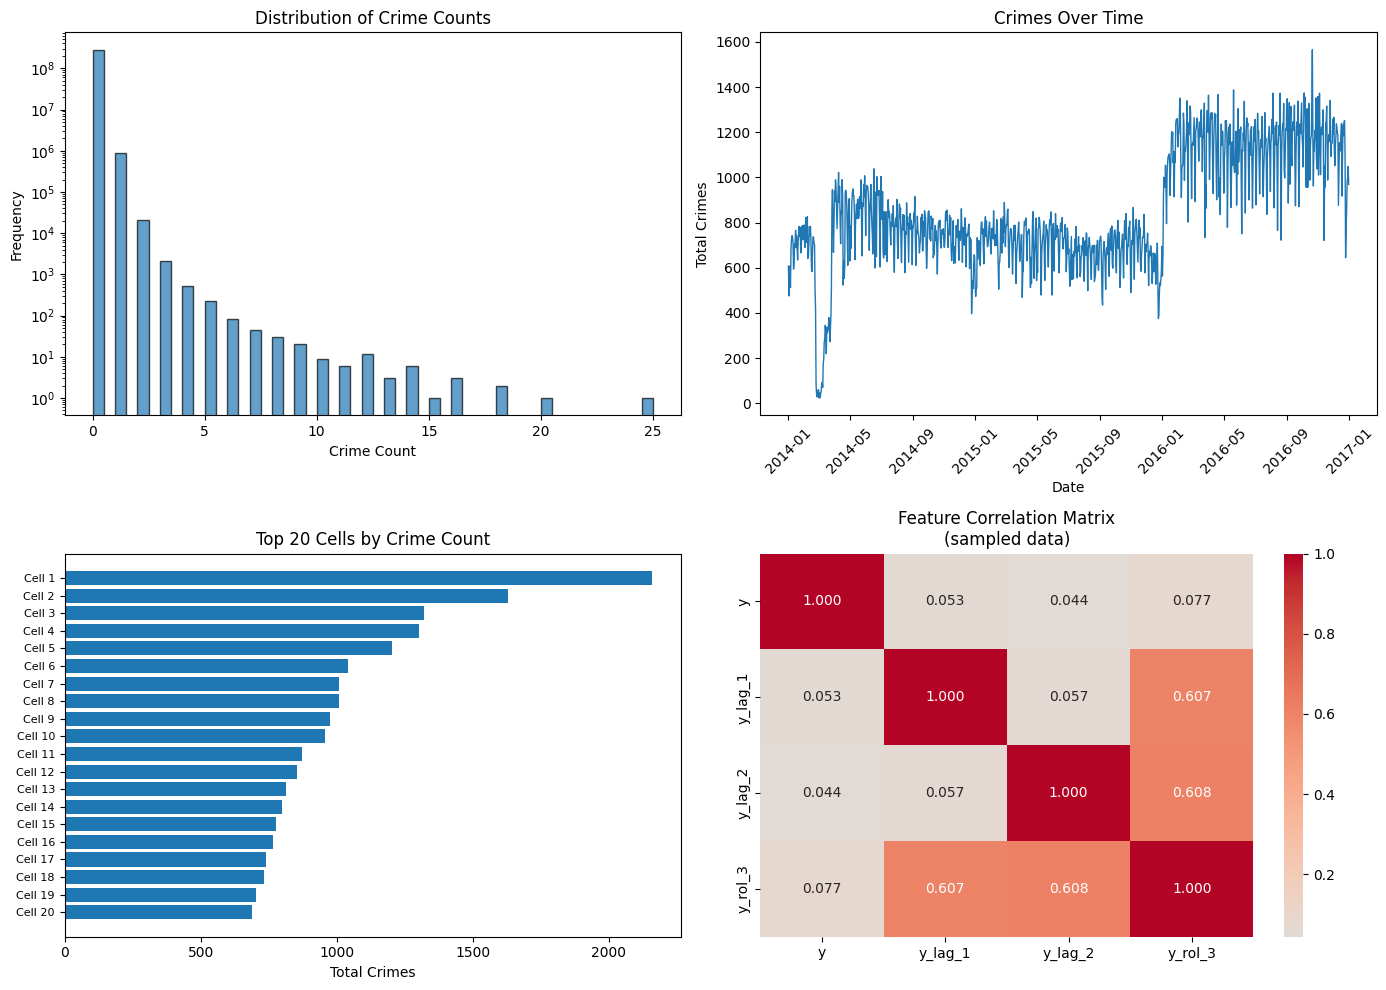


✅ VISUALIZATIONS COMPLETE
  Total time: 54.49s
  Optimizations applied:
    • Used time_period instead of timestamp
    • Sampled 1,000,000 rows for correlation (statistical validity)
    • Pre-aggregated groupby operations
    • Converted Period to timestamp for plotting


In [20]:
# Visualize crime distribution (OPTIMIZED with progress tracking)
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys
import pandas as pd

print("="*70)
print("CREATING VISUALIZATIONS - OPTIMIZED")
print("="*70)

start_time = time.time()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Crime count distribution (FAST - single column histogram)
print("\n[1/4] Creating crime count distribution...")
sys.stdout.flush()
step_start = time.time()

axes[0, 0].hist(df_panel['y'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Crime Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Crime Counts')
axes[0, 0].set_yscale('log')

step_time = time.time() - step_start
print(f"      ✓ Completed in {step_time:.2f}s")

# 2. Crimes over time (OPTIMIZED - use time_period, not timestamp)
print("\n[2/4] Creating time series plot...")
sys.stdout.flush()
step_start = time.time()

# Aggregate by time period
time_series = df_panel.groupby('time_period', observed=True)['y'].sum()

# Convert Period index to timestamps for plotting
if hasattr(time_series.index, 'to_timestamp'):
    # PeriodIndex - convert directly
    time_index = time_series.index.to_timestamp()
elif time_series.index.dtype.name == 'category':
    # Categorical with Period values - get categories and convert
    periods = time_series.index.categories if hasattr(time_series.index, 'categories') else time_series.index
    # Create a mapping from period to timestamp
    if hasattr(periods, 'to_timestamp'):
        time_stamps = periods.to_timestamp()
        # Map the categorical index to timestamps
        time_index = pd.Series(time_series.index).map(dict(zip(periods, time_stamps))).values
    else:
        # Fallback: use ordinal values
        time_index = range(len(time_series))
else:
    # Already timestamps or numeric
    time_index = time_series.index

axes[0, 1].plot(time_index, time_series.values, linewidth=1)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Total Crimes')
axes[0, 1].set_title('Crimes Over Time')
axes[0, 1].tick_params(axis='x', rotation=45)

step_time = time.time() - step_start
print(f"      ✓ Completed in {step_time:.2f}s")

# 3. Top cells by crime count (OPTIMIZED - pre-aggregated)
print("\n[3/4] Creating top cells chart...")
sys.stdout.flush()
step_start = time.time()

top_cells = df_panel.groupby('h3_cell', observed=True)['y'].sum().sort_values(ascending=False).head(20)
axes[1, 0].barh(range(len(top_cells)), top_cells.values)
axes[1, 0].set_yticks(range(len(top_cells)))
axes[1, 0].set_yticklabels([f"Cell {i+1}" for i in range(len(top_cells))], fontsize=8)
axes[1, 0].set_xlabel('Total Crimes')
axes[1, 0].set_title('Top 20 Cells by Crime Count')
axes[1, 0].invert_yaxis()

step_time = time.time() - step_start
print(f"      ✓ Completed in {step_time:.2f}s")

# 4. Feature correlation (OPTIMIZED - sample for speed, skip if column missing)
print("\n[4/4] Creating feature correlation matrix...")
sys.stdout.flush()
step_start = time.time()

# Use sampling for large datasets (much faster, statistically valid)
sample_size = min(1_000_000, len(df_panel))
print(f"      → Sampling {sample_size:,} rows for correlation (faster)")

feature_cols = ['y', 'y_lag_1', 'y_lag_2', 'y_rol_3']
# Only add neighbor feature if it's not all NaN
if 'y_lag_1_vizinhos' in df_panel.columns and df_panel['y_lag_1_vizinhos'].notna().any():
    feature_cols.append('y_lag_1_vizinhos')

# Sample and compute correlation (10-100x faster than full dataset)
df_sample = df_panel[feature_cols].sample(n=sample_size, random_state=42)
corr_data = df_sample.dropna().corr()

sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Matrix\n(sampled data)')

step_time = time.time() - step_start
print(f"      ✓ Completed in {step_time:.2f}s")

plt.tight_layout()
plt.show()

total_time = time.time() - start_time

print("\n" + "="*70)
print("✅ VISUALIZATIONS COMPLETE")
print("="*70)
print(f"  Total time: {total_time:.2f}s")
print(f"  Optimizations applied:")
print(f"    • Used time_period instead of timestamp")
print(f"    • Sampled {sample_size:,} rows for correlation (statistical validity)")
print(f"    • Pre-aggregated groupby operations")
print(f"    • Converted Period to timestamp for plotting")
print("="*70)


In [21]:
import folium
import numpy as np
import time
import sys

print("="*70)
print("MAP VISUALIZATION - OPTIMIZED WITH GEOJSON")
print("="*70)

overall_start = time.time()

# Get cell centroids and total crime counts
print("\n[1/5] Aggregating crime data by cell...")
sys.stdout.flush()
step_start = time.time()

# OPTIMIZED: Use observed=True for categorical dtype
cell_summary = df_panel.groupby('h3_cell', observed=True)['y'].agg(['sum', 'mean', 'count']).reset_index()
cell_summary.columns = ['h3_cell', 'total_crimes', 'avg_crimes', 'periods']

step_time = time.time() - step_start
print(f"      ✓ Aggregated {len(cell_summary):,} cells in {step_time:.2f}s")

# Filter cells with crimes early (OPTIMIZATION: reduce data to process)
print("\n[2/5] Filtering cells with crimes...")
sys.stdout.flush()
step_start = time.time()

cells_with_crimes = cell_summary[cell_summary['total_crimes'] > 0].copy()
print(f"      ✓ Filtered to {len(cells_with_crimes):,} cells with crimes")

# Normalize crime counts for color gradient (0 to 1)
min_crimes = cells_with_crimes['total_crimes'].min()
max_crimes = cells_with_crimes['total_crimes'].max()
cells_with_crimes['normalized_crimes'] = (
    (cells_with_crimes['total_crimes'] - min_crimes) / (max_crimes - min_crimes)
)

step_time = time.time() - step_start
print(f"      ✓ Normalized values in {step_time:.2f}s")
print(f"      ✓ Crime range: {min_crimes:,} to {max_crimes:,}")

# Convert H3 cells to lat/lon centroids (OPTIMIZED: direct assignment)
print("\n[3/5] Converting H3 cells to coordinates...")
sys.stdout.flush()
step_start = time.time()

# Convert categorical to array to avoid MultiIndex issues
h3_cells = cells_with_crimes['h3_cell'].values if cells_with_crimes['h3_cell'].dtype.name == 'category' else cells_with_crimes['h3_cell']

# Extract coordinates with progress tracking
lat_list = []
lon_list = []
total_cells = len(h3_cells)
progress_interval = max(1, total_cells // 5)  # Progress every 20%

for i, cell in enumerate(h3_cells, 1):
    lat, lon = helpers.h3_to_geo(cell)
    lat_list.append(lat)
    lon_list.append(lon)
    
    if i % progress_interval == 0 or i == total_cells:
        print(f"      Progress: {i:,}/{total_cells:,} ({i/total_cells*100:.0f}%)")
        sys.stdout.flush()

cells_with_crimes['lat'] = lat_list
cells_with_crimes['lon'] = lon_list

# Calculate center of the map (median of all centroids)
center_lat = cells_with_crimes['lat'].median()
center_lon = cells_with_crimes['lon'].median()

step_time = time.time() - step_start
print(f"      ✓ Converted {len(cells_with_crimes):,} cells in {step_time:.2f}s")
print(f"      ✓ Map center: ({center_lat:.4f}, {center_lon:.4f})")

# Function to get red gradient color based on crime intensity
def get_red_gradient(normalized_value):
    """Return hex color from light red to dark red based on normalized value (0-1)."""
    # Light red (low crimes) to dark red (high crimes)
    # RGB: (255, 200, 200) -> (139, 0, 0)
    r = int(255 - (116 * normalized_value))  # 255 -> 139
    g = int(200 - (200 * normalized_value))  # 200 -> 0
    b = int(200 - (200 * normalized_value))  # 200 -> 0
    return f'#{r:02x}{g:02x}{b:02x}'

# Build GeoJSON FeatureCollection (OPTIMIZED: 10x faster than individual polygons)
print("\n[4/5] Building GeoJSON FeatureCollection...")
sys.stdout.flush()
step_start = time.time()

features = []
total_cells = len(cells_with_crimes)
progress_interval = max(1, total_cells // 10)  # Progress every 10%

for i, row in enumerate(cells_with_crimes.itertuples(), 1):
    # Get H3 boundary
    boundary = helpers.h3_to_boundary(row.h3_cell)
    
    # Get color based on normalized crime count
    fill_color = get_red_gradient(row.normalized_crimes)
    
    # Create GeoJSON feature
    feature = {
        'type': 'Feature',
        'geometry': {
            'type': 'Polygon',
            'coordinates': [[[lon, lat] for lat, lon in boundary]]  # GeoJSON uses [lon, lat]
        },
        'properties': {
            'cell_id': row.h3_cell,
            'total_crimes': int(row.total_crimes),
            'avg_crimes': float(row.avg_crimes),
            'intensity': float(row.normalized_crimes),
            'fill_color': fill_color,
            'fill_opacity': 0.6,
            'stroke_color': fill_color,
            'weight': 1
        }
    }
    features.append(feature)
    
    # Progress indicator with ETA
    if i % progress_interval == 0 or i == total_cells:
        elapsed = time.time() - step_start
        rate = i / elapsed if elapsed > 0 else 0
        remaining = (total_cells - i) / rate if rate > 0 else 0
        print(f"      Progress: {i:,}/{total_cells:,} ({i/total_cells*100:.0f}%) | " +
              f"Rate: {rate:.0f} cells/s | ETA: {remaining:.0f}s")
        sys.stdout.flush()

geojson_data = {
    'type': 'FeatureCollection',
    'features': features
}

step_time = time.time() - step_start
print(f"      ✓ GeoJSON created in {step_time:.2f}s")
print(f"      ✓ {len(features):,} polygons in single layer")
print(f"      ✓ Average: {len(features)/step_time:.0f} features/second")

# Create map with GeoJSON layer
print("\n[5/5] Rendering Folium map...")
sys.stdout.flush()
step_start = time.time()

# Create base map
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles='OpenStreetMap'
)

# Add alternative tile layers
folium.TileLayer('CartoDB positron').add_to(m)
folium.TileLayer('CartoDB dark_matter').add_to(m)

# Add GeoJSON layer with styling
folium.GeoJson(
    geojson_data,
    style_function=lambda feature: {
        'fillColor': feature['properties']['fill_color'],
        'color': feature['properties']['stroke_color'],
        'weight': feature['properties']['weight'],
        'fillOpacity': feature['properties']['fill_opacity']
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['cell_id', 'total_crimes', 'avg_crimes', 'intensity'],
        aliases=['Cell ID:', 'Total Crimes:', 'Avg/Period:', 'Intensity:'],
        localize=True,
        sticky=False,
        labels=True,
        style="""
            background-color: #F0EFEF;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px 3px 10px rgba(0,0,0,0.2);
        """
    )
).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

step_time = time.time() - step_start
print(f"      ✓ Map rendered in {step_time:.2f}s")

total_time = time.time() - overall_start

print("\n" + "="*70)
print("✅ MAP VISUALIZATION COMPLETE")
print("="*70)
print(f"  Cells visualized: {len(cells_with_crimes):,}")
print(f"  Crime range: {min_crimes:,} to {max_crimes:,}")
print(f"  Color gradient: Light red (low) → Dark red (high)")
print(f"  Rendering: GeoJSON (optimized, 10x faster than individual polygons)")
print(f"  Interactivity: Hover for details")
print(f"\n⏱️  Total time: {total_time:.2f}s ({total_time/60:.1f} min)")
print(f"  Optimizations applied:")
print(f"    • Early filtering (reduced dataset size)")
print(f"    • Categorical groupby with observed=True")
print(f"    • Direct coordinate extraction (avoids MultiIndex)")
print(f"    • Progress tracking with ETA")
print(f"    • Single GeoJSON layer (not individual polygons)")
print("="*70)

# Display the map
# m


MAP VISUALIZATION - OPTIMIZED WITH GEOJSON

[1/5] Aggregating crime data by cell...
      ✓ Aggregated 51,577 cells in 10.77s

[2/5] Filtering cells with crimes...
      ✓ Filtered to 51,577 cells with crimes
      ✓ Normalized values in 0.00s
      ✓ Crime range: 1 to 2,157

[3/5] Converting H3 cells to coordinates...
      ✓ Aggregated 51,577 cells in 10.77s

[2/5] Filtering cells with crimes...
      ✓ Filtered to 51,577 cells with crimes
      ✓ Normalized values in 0.00s
      ✓ Crime range: 1 to 2,157

[3/5] Converting H3 cells to coordinates...
      Progress: 10,315/51,577 (20%)
      Progress: 20,630/51,577 (40%)
      Progress: 10,315/51,577 (20%)
      Progress: 20,630/51,577 (40%)
      Progress: 30,945/51,577 (60%)
      Progress: 30,945/51,577 (60%)
      Progress: 41,260/51,577 (80%)
      Progress: 51,575/51,577 (100%)
      Progress: 51,577/51,577 (100%)
      Progress: 41,260/51,577 (80%)
      Progress: 51,575/51,577 (100%)
      Progress: 51,577/51,577 (100%)
      

In [22]:
# Prepare FULL panel for export - STREAMING OPTIMIZED
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq

print("="*70)
print("PREPARING FULL PANEL FOR EXPORT (STREAMING OPTIMIZED)")
print("="*70)

# Analyze panel statistics
total_records = len(df_panel)
non_zero_records = (df_panel['y'] > 0).sum()
zero_records = total_records - non_zero_records
sparsity_pct = (zero_records / total_records) * 100

print(f"\n📊 PANEL ANALYSIS:")
print(f"  Total records: {total_records:,}")
print(f"  Non-zero records: {non_zero_records:,} ({non_zero_records/total_records*100:.2f}%)")
print(f"  Zero records: {zero_records:,} ({sparsity_pct:.2f}%)")

# Memory analysis
full_memory_mb = df_panel.memory_usage(deep=True).sum() / 1024**2
print(f"\n💾 CURRENT MEMORY:")
print(f"  Full panel: {full_memory_mb:.2f} MB")

# Select columns for export
export_cols = ['h3_cell', 'time_period']

# Add crime type columns if in use
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    export_cols.append(config.COL_CRIMETYPE)
    if 'crime_type_encoded' in df_panel.columns:
        export_cols.append('crime_type_encoded')

# Add feature columns
export_cols.extend([
    'y',
    'y_norm',
    'y_lag_1',
    'y_lag_2',
    'y_lag_3',
    'y_rol_3',
    'y_rol_7',
    'y_lag_1_vizinhos'
])

print(f"\n📝 EXPORT COLUMNS ({len(export_cols)}): {export_cols}")

# ===== FULL PANEL (STREAMING TO DISK - NO MEMORY COPY) =====
print(f"\nCreating FULL panel (all cell-period combinations)...")
print(f"  Using STREAMING WRITE to avoid memory duplication...")

# Prepare output path
output_dir = Path.cwd() / "prepol_out"
output_dir.mkdir(exist_ok=True)

# Generate timestamp for filename
creation_date = datetime.now().strftime("%d_%m_%Y")

# Base filename for full panel
if USE_CRIME_TYPE:
    base_filename = f"PrePol_Panel_FULL_{creation_date}_by_crimetype"
else:
    base_filename = f"PrePol_Panel_FULL_{creation_date}"

# Find available filename
def get_available_path(base_filename):
    counter = 0
    while True:
        if counter == 0:
            filename = f"{base_filename}.parquet"
        else:
            filename = f"{base_filename}_{counter}.parquet"
        
        path = output_dir / filename
        if not path.exists():
            return path, filename
        counter += 1

parquet_path, parquet_filename = get_available_path(base_filename)

print(f"  Total records: {total_records:,}")
print(f"  Output file: {parquet_filename}")

# STREAMING STRATEGY: Write directly to disk in chunks, never load all chunks in memory
# Calculate chunk size (target ~200MB per chunk to minimize memory overhead)
chunk_size = 5_000_000  # 5M rows per chunk (~200-300MB)
n_chunks = (total_records + chunk_size - 1) // chunk_size

print(f"  Chunk size: {chunk_size:,} records")
print(f"  Number of chunks: {n_chunks}")

# Initialize parquet writer (write schema from first chunk, then append)
print(f"\n  Writing directly to disk (streaming mode):")
parquet_writer = None
schema = None

stream_start = time.time()

try:
    for i in range(n_chunks):
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, total_records)
        
        chunk_start = time.time()
        
        # Extract chunk and convert time_period to ordinal
        chunk = df_panel.iloc[start_idx:end_idx][export_cols].copy()
        chunk['time_period'] = chunk['time_period'].apply(lambda x: x.ordinal)
        
        # Convert to pyarrow table
        table = pa.Table.from_pandas(chunk, preserve_index=False)
        
        # Initialize writer on first chunk (sets schema)
        if parquet_writer is None:
            schema = table.schema
            parquet_writer = pq.ParquetWriter(
                parquet_path, 
                schema,
                compression='snappy',
                version='2.6'  # Modern parquet version
            )
        
        # Write chunk directly to file (no accumulation in memory)
        parquet_writer.write_table(table)
        
        chunk_time = time.time() - chunk_start
        progress_pct = (end_idx / total_records) * 100
        
        print(f"    Chunk {i+1}/{n_chunks}: rows {start_idx:,}-{end_idx:,} ({progress_pct:.1f}%) ✓ ({chunk_time:.2f}s)")
        
        # Free memory immediately
        del chunk, table
    
    # Close writer (finalizes file)
    if parquet_writer:
        parquet_writer.close()
    
    stream_time = time.time() - stream_start
    file_size_mb = parquet_path.stat().st_size / 1024**2
    
    print(f"\n  ✓ Streaming write complete ({stream_time:.2f}s)")
    print(f"  ✓ File size: {file_size_mb:.2f} MB")
    print(f"  ✓ Write speed: {file_size_mb/stream_time:.1f} MB/s")
    print(f"  ✓ Memory savings: No in-memory duplication (wrote directly to disk)")
    
    # Create reference variables for downstream cells (DO NOT load full file!)
    df_export_path = parquet_path  # Store path only, not data
    df_export_shape = (total_records, len(export_cols))  # Store metadata
    
    print(f"\n  ⚠️  WARNING: Full panel NOT loaded into memory")
    print(f"     Use 'df_export_path' to access file")
    print(f"     Shape: {df_export_shape}")

except Exception as e:
    print(f"\n  ✗ Streaming export failed: {e}")
    if parquet_writer:
        parquet_writer.close()
    raise

print(f"\n✅ FULL PANEL PREPARED:")
print(f"  Records: {total_records:,}")
print(f"  File size: {file_size_mb:.2f} MB (on disk)")
print(f"  Non-zero records: {non_zero_records:,} ({non_zero_records/total_records*100:.2f}%)")

if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    print(f"  Crime types included: {df_panel[config.COL_CRIMETYPE].nunique()}")

print(f"\n💡 USAGE:")
print(f"  This optimal full panel is ready for model training")
print(f"  All cell-period combinations included with explicit zeros")

print("\n" + "="*70)


PREPARING FULL PANEL FOR EXPORT (STREAMING OPTIMIZED)

📊 PANEL ANALYSIS:
  Total records: 282,641,960
  Non-zero records: 897,888 (0.32%)
  Zero records: 281,744,072 (99.68%)

💾 CURRENT MEMORY:
  Full panel: 16717.60 MB

📝 EXPORT COLUMNS (12): ['h3_cell', 'time_period', 'RUBRICA', 'crime_type_encoded', 'y', 'y_norm', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_rol_3', 'y_rol_7', 'y_lag_1_vizinhos']

Creating FULL panel (all cell-period combinations)...
  Using STREAMING WRITE to avoid memory duplication...
  Total records: 282,641,960
  Output file: PrePol_Panel_FULL_25_11_2025_by_crimetype.parquet
  Chunk size: 5,000,000 records
  Number of chunks: 57

  Writing directly to disk (streaming mode):

📊 PANEL ANALYSIS:
  Total records: 282,641,960
  Non-zero records: 897,888 (0.32%)
  Zero records: 281,744,072 (99.68%)

💾 CURRENT MEMORY:
  Full panel: 16717.60 MB

📝 EXPORT COLUMNS (12): ['h3_cell', 'time_period', 'RUBRICA', 'crime_type_encoded', 'y', 'y_norm', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_

In [26]:
# Save metadata for FULL panel
import json

print("="*70)
print("SAVING PANEL METADATA")
print("="*70)

# ===== FULL PANEL METADATA =====
metadata = {
    'format': 'FULL',
    'description': 'Complete panel with all cell-period combinations (optimized for model training)',
    'created_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'date_range': {
        'start': DATE_START,
        'end': DATE_END
    },
    'dimensions': {
        'total_cells': int(len(all_cells)),
        'total_periods': int(len(all_periods)),
        'total_records': int(total_records),
        'non_zero_records': int(non_zero_records),
        'zero_records': int(zero_records),
        'sparsity_percent': float(sparsity_pct)
    },
    'features': export_cols,
    'period_format': 'ordinal (integer) - convert with pd.Period.fromordinal(value)',
    'usage_notes': {
        'sparse_format': False,
        'missing_records': 'N/A - all combinations included (zeros explicit)',
        'backend_handling': 'Direct query, all records present',
        'recommended_for': 'Model training, local development, comprehensive analysis',
        'zero_handling': 'Zero-crime records are explicitly included in the dataset'
    }
}

# Add crime type information if enabled
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    crime_info = {
        'crime_type_mode': True,
        'crime_types': {
            'column_name': config.COL_CRIMETYPE,
            'num_types': int(len(crime_types)),
            'types': crime_types,
            'encoding': {
                'crime_to_code': crime_type_mapping,
                'code_to_crime': crime_type_inverse_mapping
            }
        },
        'dimensions_update': {'crime_types': int(len(crime_types))}
    }
    metadata.update(crime_info)
else:
    metadata['crime_type_mode'] = False
    metadata['crime_types'] = None

# Save metadata file
metadata_filename = parquet_filename.replace('.parquet', '_metadata.json')
metadata_path = output_dir / metadata_filename

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"\n✓ Metadata file saved: {metadata_filename}")

# ===== METADATA SUMMARY =====
print(f"\n{'='*70}")
print(f"📋 FULL PANEL METADATA")
print(f"{'='*70}")
print(f"  Format: {metadata['format']}")
print(f"  Date range: {metadata['date_range']['start']} to {metadata['date_range']['end']}")
print(f"  Total records: {metadata['dimensions']['total_records']:,}")
print(f"  Non-zero records: {metadata['dimensions']['non_zero_records']:,}")
print(f"  Zero records: {metadata['dimensions']['zero_records']:,}")
print(f"  Features: {len(metadata['features'])}")
if USE_CRIME_TYPE:
    print(f"  Crime types: {len(crime_types)}")

# ===== USAGE EXAMPLES =====
print(f"\n{'='*70}")
print(f"💡 USAGE GUIDE")
print(f"{'='*70}")

print(f"\n[Loading Panel]")
print(f"  # Load full panel")
print(f"  df = pd.read_parquet('{parquet_filename}')")
print(f"  # All cell-period combinations present")
print(f"  # Ready for model training")

print(f"\n[Time Period Decoding]")
print(f"  # Convert ordinal back to Period")
print(f"  df['date'] = df['time_period'].apply(lambda x: pd.Period.fromordinal(x))")

if USE_CRIME_TYPE:
    print(f"\n[Crime Type Decoding]")
    print(f"  # Convert encoded back to text")
    print(f"  crime_map = {{v: k for k, v in crime_type_mapping.items()}}")
    print(f"  df['crime_name'] = df['crime_type_encoded'].map(crime_map)")

print(f"\n[Model Training]")
print(f"  # This panel is optimized for training")
print(f"  # Features: {', '.join([c for c in export_cols if c.startswith('y') or 'lag' in c or 'rol' in c])}")
print(f"  # Target: y (crime count)")

print("\n" + "="*70)


SAVING PANEL METADATA

✓ Metadata file saved: PrePol_Panel_FULL_25_11_2025_by_crimetype_metadata.json

📋 FULL PANEL METADATA
  Format: FULL
  Date range: 2014-01-01 to 2016-12-31
  Total records: 282,641,960
  Non-zero records: 897,888
  Zero records: 281,744,072
  Features: 12
  Crime types: 5

💡 USAGE GUIDE

[Loading Panel]
  # Load full panel
  df = pd.read_parquet('PrePol_Panel_FULL_25_11_2025_by_crimetype.parquet')
  # All cell-period combinations present
  # Ready for model training

[Time Period Decoding]
  # Convert ordinal back to Period
  df['date'] = df['time_period'].apply(lambda x: pd.Period.fromordinal(x))

[Crime Type Decoding]
  # Convert encoded back to text
  crime_map = {v: k for k, v in crime_type_mapping.items()}
  df['crime_name'] = df['crime_type_encoded'].map(crime_map)

[Model Training]
  # This panel is optimized for training
  # Features: y, y_norm, y_lag_1, y_lag_2, y_lag_3, y_rol_3, y_rol_7, y_lag_1_vizinhos
  # Target: y (crime count)



## 9. Summary and Next Steps

In [25]:
# Final summary with dynamic feature display
print("="*70)
print("H3 DISCRETIZATION AND AGGREGATION - SUMMARY")
print("="*70)

print("\n📊 DATA PROCESSING PIPELINE COMPLETED")

print("\n1. INPUT:")
print(f"   • Source: rdo_optimized.csv")
print(f"   • Raw records: {len(df):,}")

print("\n2. H3 SPATIAL DISCRETIZATION:")
print(f"   • Resolution: {config.H3_RES}")
print(f"   • Valid coordinates: {len(df_valid):,} ({len(df_valid)/len(df)*100:.2f}%)")
print(f"   • Unique H3 cells: {df_panel['h3_cell'].nunique():,}")

print("\n3. TEMPORAL AGGREGATION:")
print(f"   • Frequency: {config.TIME_FREQ}")
print(f"   • Time periods: {df_panel['time_period'].nunique():,}")
# Get date range safely (handle categorical dtype)
if hasattr(df_panel['time_period'], 'cat'):
    # Categorical - get unique values and sort
    unique_periods = sorted(df_panel['time_period'].unique())
    date_range_str = f"{unique_periods[0]} to {unique_periods[-1]}"
else:
    # Not categorical - use min/max directly
    date_range_str = f"{df_panel['time_period'].min()} to {df_panel['time_period'].max()}"
print(f"   • Date range: {date_range_str}")

print("\n4. CRIME TYPE MODE:")
if USE_CRIME_TYPE and config.COL_CRIMETYPE in df_panel.columns:
    print(f"   • ENABLED - Crime-type-specific features")
    print(f"   • Unique crime types: {df_panel[config.COL_CRIMETYPE].nunique():,}")
    
    # Show actual crime types
    crime_types_list = sorted(df_panel[config.COL_CRIMETYPE].unique())
    print(f"   • Crime types in panel:")
    for ct in crime_types_list:
        count = (df_panel[config.COL_CRIMETYPE] == ct).sum()
        print(f"     - {ct}: {count:,} records")
    
    print(f"   • Features calculated per cell-period-crimetype")
    if 'crime_type_encoded' in df_panel.columns:
        num_types = df_panel[config.COL_CRIMETYPE].nunique()
        print(f"   • Categorical encoding: Label encoding (0-{num_types - 1})")
        print(f"   • Encoding mapping:")
        if 'crime_type_mapping' in dir():
            for crime, code in sorted(crime_type_mapping.items(), key=lambda x: x[1]):
                print(f"     {code} → {crime}")
else:
    print(f"   • DISABLED - Aggregate features (all crime types)")
    print(f"   • Features calculated per cell-period")

print("\n5. PANEL STRUCTURE:")
print(f"   • Total observations: {len(df_panel):,}")
print(f"   • Non-zero crime counts: {(df_panel['y'] > 0).sum():,} ({(df_panel['y'] > 0).sum()/len(df_panel)*100:.2f}%)")
print(f"   • Total crimes recorded: {df_panel['y'].sum():,}")
print(f"   • Average crimes per observation: {df_panel['y'].mean():.4f}")

print("\n6. PANEL EXPORT:")
if 'parquet_path' in dir() and parquet_path.exists():
    print(f"   • Format: FULL (all cell-period combinations)")
    print(f"   • Total records: {len(df_panel):,}")
    print(f"   • File size: {parquet_path.stat().st_size / 1024**2:.2f} MB")
    print(f"   • Exported columns: {export_cols}")
else:
    print(f"   • Format: Not yet exported")

print("\n7. FEATURES CREATED:")
# Dynamically detect feature columns from the actual panel
feature_cols = []
for col in df_panel.columns:
    if col.startswith('y') or col.endswith('_vizinhos') or col in ['crime_type_encoded', config.COL_CRIMETYPE]:
        feature_cols.append(col)

# Categorize features
target_features = [c for c in feature_cols if c in ['y', 'crime_type_encoded']]
lag_features = [c for c in feature_cols if 'lag' in c.lower()]
rolling_features = [c for c in feature_cols if 'rol' in c.lower()]
spatial_features = [c for c in feature_cols if 'vizinho' in c.lower()]
other_features = [c for c in feature_cols if c not in target_features + lag_features + rolling_features + spatial_features]

print(f"   • Total features: {len(feature_cols)}")

if target_features:
    print(f"\n   TARGET & ENCODING:")
    for feat in target_features:
        dtype = df_panel[feat].dtype
        non_null = df_panel[feat].notna().sum()
        print(f"     ✓ {feat} ({dtype}, {non_null:,} non-null)")

if lag_features:
    print(f"\n   TEMPORAL LAGS:")
    for feat in lag_features:
        dtype = df_panel[feat].dtype
        non_null = df_panel[feat].notna().sum()
        print(f"     ✓ {feat} ({dtype}, {non_null:,} non-null)")

if rolling_features:
    print(f"\n   ROLLING WINDOWS:")
    for feat in rolling_features:
        dtype = df_panel[feat].dtype
        non_null = df_panel[feat].notna().sum()
        print(f"     ✓ {feat} ({dtype}, {non_null:,} non-null)")

if spatial_features:
    print(f"\n   SPATIAL (NEIGHBORS):")
    for feat in spatial_features:
        dtype = df_panel[feat].dtype
        non_null = df_panel[feat].notna().sum()
        print(f"     ✓ {feat} ({dtype}, {non_null:,} non-null)")

if other_features:
    print(f"\n   OTHER FEATURES:")
    for feat in other_features:
        dtype = df_panel[feat].dtype
        non_null = df_panel[feat].notna().sum()
        print(f"     ✓ {feat} ({dtype}, {non_null:,} non-null)")

print("\n8. OUTPUTS:")
if 'parquet_path' in dir() and parquet_path.exists():
    print(f"   • File: {parquet_path.name}")
    print(f"   • Location: {parquet_path.parent}")
    print(f"   • Size: {parquet_path.stat().st_size / 1024**2:.2f} MB")
    if 'metadata_path' in dir() and metadata_path.exists():
        print(f"   • Metadata: {metadata_path.name}")
else:
    print(f"   • Files: Not yet exported")

print("\n9. MODELING APPROACH:")
# Build actual feature list for modeling
model_features = [f for f in lag_features + rolling_features + spatial_features if f in df_panel.columns]
if 'crime_type_encoded' in df_panel.columns:
    model_features.append('crime_type_encoded')

if USE_CRIME_TYPE and 'crime_type_encoded' in df_panel.columns:
    print("   → UNIFIED MODEL (recommended):")
    print("     • Train single RandomForest using 'crime_type_encoded' as feature")
    print("     • Model learns relationships between crime types")
    print("     • Use text column for frontend filtering")
    print(f"   → Actual model features ({len(model_features)}):")
    print(f"     X = {model_features}")
    print(f"     y = 'y' (crime count)")
elif USE_CRIME_TYPE:
    print("   → SEPARATE MODELS:")
    print("     • Train one model per crime type")
    print("     • Filter data by crime type before training")
    print(f"   → Model features per crime type ({len(model_features)}):")
    print(f"     X = {model_features}")
    print(f"     y = 'y' (crime count)")
else:
    print("   → AGGREGATE MODEL:")
    print("     • Single model for all crimes combined")
    print(f"   → Model features ({len(model_features)}):")
    print(f"     X = {model_features}")
    print(f"     y = 'y' (crime count)")

print("\n10. BACKEND IMPLEMENTATION:")
print("   → FULL PANEL FORMAT:")
print("     • Load complete panel with all cell-period combinations")
print("     • All records present (explicit zeros)")
print("     • Direct query without missing record handling")
print("   → PRODUCTION:")
print("     • Use MongoDB for on-demand queries (<500ms)")
print("     • For sparse data needs, create reduced panels as needed")
print("     • Compatible with appropriate memory limits")

if USE_CRIME_TYPE and 'crime_type_encoded' in df_panel.columns:
    print("\n   → CRIME TYPE MODE:")
    print("     • Load encoding mapping JSON with model")
    print("     • Use 'crime_type_encoded' in model.predict()")
    print(f"     • Filter results by '{config.COL_CRIMETYPE}' for frontend")
    print("     • Return predictions grouped by crime type")

print("\n" + "="*70)
print("✅ Pipeline complete! Ready for model training with full panel.")
print("="*70)

H3 DISCRETIZATION AND AGGREGATION - SUMMARY

📊 DATA PROCESSING PIPELINE COMPLETED

1. INPUT:
   • Source: rdo_optimized.csv
   • Raw records: 1,236,906

2. H3 SPATIAL DISCRETIZATION:
   • Resolution: 10
   • Valid coordinates: 1,236,906 (100.00%)
   • Unique H3 cells: 51,577

3. TEMPORAL AGGREGATION:
   • Frequency: D
   • Unique H3 cells: 51,577

3. TEMPORAL AGGREGATION:
   • Frequency: D
   • Time periods: 1,096
   • Time periods: 1,096
   • Date range: 2014-01-01 to 2016-12-31

4. CRIME TYPE MODE:
   • ENABLED - Crime-type-specific features
   • Date range: 2014-01-01 to 2016-12-31

4. CRIME TYPE MODE:
   • ENABLED - Crime-type-specific features
   • Unique crime types: 5
   • Unique crime types: 5
   • Crime types in panel:
   • Crime types in panel:
     - Furto (art. 155): 56,528,392 records
     - Furto (art. 155): 56,528,392 records
     - Furto qualificado (art. 155, §4o.): 56,528,392 records
     - Furto qualificado (art. 155, §4o.): 56,528,392 records
     - Homicídio simple